Created on Oct 22, 2025
Purpose: Personal project to proactively detect pandemics or epidemics 
@author: Moses Kalyango
Tutor: Prof Bhavana

1. Loading neccesary libraries

In [1]:
import pandas as pd #create an instance of the panda library/class as pd
import numpy as np #create an instance of the numpy library/class as np
import matplotlib.pyplot as plt #create an instance of pyplot a module of the matplotlib library as plt
import seaborn as sns #create an instance of the seaborn library/class as sns
from matplotlib.ticker import ScalarFormatter #from ticker module with in the matplotlib library import a submodule called scalar formatter. 
import warnings #import thr warning library 
import gc #import garbage collector library to clean up pandas dataframes from memory where need be with in the program
warnings.filterwarnings("ignore")

2. Importing data from the different datasets from local storage to data frames for analysis

Files:-
mobility.csv, epidemiology.csv,economy.csv, oxford-government-response.csv, vaccinations.csv, worldbank indicators.csv', by-sex.csv, by-age.csv, lawatlas-emergency-declarations.csv,geography.csv,
health.csv, hospitalizations.csv, demographics.csv, dataset_headers.csv, facility-boundary-us-drive.csv, facility-boundary-us-transit.csv, facility-boundary-us-walk.csv, facility-boundary-us-all.csv, weather.csv, vaccination-search-insights.csv, Global_vaccination_search_insights.csv, index.csv

Due to the large set of datasets, its been broken down into four blocks for importing.

In [ ]:
2.1 Block 1

In [2]:
#Epidemiology data (contains cases of sick and deaths) loading and independent variable selections based on the project objectives to save memory resources
Epidemiology_df = pd.read_csv(
    "D:/Datasets/Pandemic datasets/google health data/epidemiology.csv",
    parse_dates=['date'], #Parse the date column immediately to allow for better time series plots
    usecols=['date','location_key', 'new_confirmed', 'new_deceased', 'new_recovered', 'new_tested',
             'cumulative_confirmed', 'cumulative_deceased', 'cumulative_recovered', 'cumulative_tested'], #Feature selection to allow for more optimal memory use.
    low_memory=False #Forces panda instance to read the file in one go and correctly identify the corresponding datatype of the columns or features. 
)

print(f"Epidemiology  data Loaded: {len(Epidemiology_df):,} rows") #len counts the number of data instances or rows loaded

Epidemiology  data Loaded: 12,525,825 rows


2.2 Block 2

In [76]:
#Location data (Geographic data of affected areas) loading and feature selection to save memory and reducing chances of over fitting. 
location_df = pd.read_csv("D:/Datasets/Pandemic datasets/google health data/geography.csv", 
                          usecols=['location_key','latitude','longitude', 'elevation_m','area_sq_km','area_rural_sq_km','area_urban_sq_km'] # Feature selection: features dropped are:- openstreetmap_id,
)
print(f"Location data loaded: {len(location_df):,} rows")

#Hospitalization data loading


start_date = '2019-01-01' 
 
hosp_df = pd.read_csv("D:/Datasets/Pandemic datasets/google health data/hospitalizations.csv",
    parse_dates=['date'], #Convert 'date' to real datetime
    dtype={'location_key': 'category'}  # Save memory
).query('date >= @start_date') # Filtering out old redundant data before 2019 

print(f"hospitalization  data Loaded: {len(hosp_df):,} rows")

#Categorization by-age data loading
by_age_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/by-age.csv")

print(f"categorization by-age  data Loaded: {len(by_age_df):,} rows")

#Categorization by-sex data loading
by_sex_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/by-sex.csv")

print(f"Categorization by-sex  data Loaded: {len(by_sex_df):,} rows")

Location data loaded: 22,130 rows
hospitalization  data Loaded: 1,153,972 rows
categorization by-age  data Loaded: 3,822,577 rows
Categorization by-sex  data Loaded: 3,848,340 rows


2.3 Block 3

In [61]:
#mobility indicator data loading
mobility_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/mobility.csv")

print(f"mobility  data Loaded: {len(mobility_df):,} rows")

#vaccinations tracking data loading
vaccinations_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/vaccinations.csv")

print(f"vaccinations tracking data Loaded: {len(vaccinations_df):,} rows")

#government response data loading
govt_r_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/oxford-government-response.csv")

print(f"government response  data Loaded: {len(govt_r_df):,} rows")

#Economic indicator data loading
economy_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/economy.csv")

print(f"economy  data Loaded: {len(economy_df):,} rows")

#Health indicators data loading
health_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/health.csv")

print(f"health indicator  data Loaded: {len(health_df):,} rows")


mobility  data Loaded: 6,321,226 rows
vaccinations tracking data Loaded: 2,545,118 rows
government response  data Loaded: 303,969 rows
economy  data Loaded: 404 rows
health indicator  data Loaded: 3,504 rows


2.4 Block 4

In [62]:


#index data loading
index_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/index.csv",
                      usecols=['location_key','country_code','country_name','subregion1_code','subregion1_name','subregion2_code','subregion2_name','aggregation_level'])
#Feature selection dropped place_id, wikidata, datacommons, 3166-1-alpha-2, 3166-1-alpha-3 since these were not relevant to the project

print(f"index  data Loaded: {len(index_df):,} rows")

#worldbank indicators data loading
#WB_I_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/worldbank indicators.csv")
#Dataset disabled much as its available because its not relevant to the project objectives.
#print(f"worldbank indicators data Loaded: {len(WB_I_df):,} rows")

#Weather tracking data loading
weather_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/weather.csv")

print(f"Weather tracking data Loaded: {len(weather_df):,} rows")

#COVID-19 vaccination search insights data
#US only 
vaccine_search_us_df = pd.read_csv("D:/Datasets/Pandemic datasets/google health data/vaccination-search-insights.csv")
print(f"US COVID-19 vaccination search insights data loaded: {len(vaccine_search_us_df):,} rows")
#Global
vaccine_search_gb_df = pd.read_csv("D:/Datasets/Pandemic datasets/google health data/Global_vaccination_search_insights.csv")
print(f"Global COVID-19 vaccination search insights data loaded:{len(vaccine_search_gb_df):,} rows")

#Demographics data

demographics_df = pd.read_csv("D:/Datasets/Pandemic datasets/google health data/demographics.csv")
print(f"Demographics data loaded:{len(demographics_df):,} rows")

#US only vaccination access data loading
vc_us_drive_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/facility-boundary-us-drive.csv",
                       usecols=['facility_provider_id', 'facility_name', 'facility_latitude', 'facility_longitude','facility_country_region','facility_country_region_code','facility_sub_region_1',
                                'facility_sub_region_1_code','facility_sub_region_2','facility_sub_region_2_code','facility_region_place_id','mode_of_transportation','travel_time_threshold_minutes'])
vc_us_transit_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/facility-boundary-us-transit.csv",
                       usecols=['facility_provider_id', 'facility_name', 'facility_latitude', 'facility_longitude','facility_country_region','facility_country_region_code','facility_sub_region_1',
                                'facility_sub_region_1_code','facility_sub_region_2','facility_sub_region_2_code','facility_region_place_id','mode_of_transportation','travel_time_threshold_minutes'])
vc_us_walk_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/facility-boundary-us-walk.csv",
                       usecols=['facility_provider_id', 'facility_name', 'facility_latitude', 'facility_longitude','facility_country_region','facility_country_region_code','facility_sub_region_1',
                                'facility_sub_region_1_code','facility_sub_region_2','facility_sub_region_2_code','facility_region_place_id','mode_of_transportation','travel_time_threshold_minutes'])
vc_us_all_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/facility-boundary-us-all.csv",
                       usecols=['facility_provider_id', 'facility_name', 'facility_latitude', 'facility_longitude','facility_country_region','facility_country_region_code','facility_sub_region_1',
                                'facility_sub_region_1_code','facility_sub_region_2','facility_sub_region_2_code','facility_region_place_id','mode_of_transportation','travel_time_threshold_minutes'])
#Feature selection drops facility_place_id and facility_catchment_boundary from the dataset because they are not relevant to the project. 

print(f"Vaccination access data 1 Loaded: {len(vc_us_drive_df):,} rows")
print(f"Vaccination access data 2 Loaded: {len(vc_us_transit_df):,} rows")
print(f"Vaccination access data 3 Loaded: {len(vc_us_walk_df):,} rows")
print(f"Vaccination access data 4 Loaded: {len(vc_us_all_df):,} rows")

#emergency-declarations data loading disabled
#lawatlas_df= pd.read_csv("D:/Datasets/Pandemic datasets/google health data/lawatlas-emergency-declarations.csv")
#print(f"emergency-declarations  data Loaded: {len(lawatlas_df):,} rows")
#More granular but similar to government responses so can generically be covered by the later and also because the project doesn't neccesarily need that kind of granularity. 


index  data Loaded: 22,963 rows
Weather tracking data Loaded: 21,680,590 rows
US COVID-19 vaccination search insights data loaded: 248,828 rows
Global COVID-19 vaccination search insights data loaded:2,691,237 rows
Demographics data loaded:21,689 rows
Vaccination access data 1 Loaded: 105,906 rows
Vaccination access data 2 Loaded: 105,906 rows
Vaccination access data 3 Loaded: 141,208 rows
Vaccination access data 4 Loaded: 353,020 rows


3. Memory garbage clean up in case there are memory issues. Switch from one dataframe to another to clean up

In [2]:
del Epidemiology_df
gc.collect() #Manualy trigger garbage collection 
print("Hospital data deleted and garbage collected")

NameError: name 'Epidemiology_df' is not defined

4. Review datasets structure

In [9]:
#Google health dataset structure analysis 
print("****************************************************************************************************************************************")
#Google COVID mobility data data structure to identify details of features/parameters in the dataset
print("********************Epidemiology data********************")
print(Epidemiology_df.info())
print("********************location data********************")
print(location_df.info())
print("********************hospital data********************")
print(hosp_df.info())
print("********************Segmentation by age data********************")
print(by_age_df.info())
print("********************by sex data********************")
print(by_sex_df.info())
print("********************Economic indicators data********************")
print(economy_df.info())
print("************health indicators data********************")
print(health_df.info())
print("********************Mobility tracking data********************")
print(mobility_df.info())
print("********************Vaccinations tracking data********************")
print(vaccinations_df.info())
print("********************Governance tracking data********************")
print(govt_r_df.info())
print("****************************************************************************************************************************************")

****************************************************************************************************************************************
********************Epidemiology data********************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12525825 entries, 0 to 12525824
Data columns (total 10 columns):
 #   Column                Dtype         
---  ------                -----         
 0   date                  datetime64[ns]
 1   location_key          object        
 2   new_confirmed         float64       
 3   new_deceased          float64       
 4   new_recovered         float64       
 5   new_tested            float64       
 6   cumulative_confirmed  float64       
 7   cumulative_deceased   float64       
 8   cumulative_recovered  float64       
 9   cumulative_tested     float64       
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 955.6+ MB
None
********************location data********************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2213

In [9]:
# USER: Change these anytime
start = '2020-03-01'
end   = '2022-12-31'

# ONE-SHOT: Fast aggregation + perfect date handling
daily = pd.DataFrame({
    'new_confirmed'            : Epidemiology_df.groupby('date')['new_confirmed'].sum(),
    'new_hospitalized_patients': hosp_df.groupby('date')['new_hospitalized_patients'].sum(),
    'new_confirmed_male'       : by_sex_df.groupby('date')['new_confirmed_male'].sum(),
    'new_confirmed_female'     : by_sex_df.groupby('date')['new_confirmed_female'].sum()
})

# THE FIX: Convert index to real datetime + sort + reindex to full daily range
daily.index = pd.to_datetime(daily.index, errors='coerce')   # bad dates → NaT
daily = daily.sort_index()                                   # chronological order
daily = daily.asfreq('D', fill_value=0)                      # fill missing days with 0

# Safe slicing (this NEVER fails)
daily = daily.loc[start:end]  # works even if start/end not in index

# PLOT — beautiful and instant
plt.figure(figsize=(16, 8))

plt.plot(daily.index, daily['new_confirmed'],            label='New Confirmed Cases',      color='#1f77b4', lw=2.8)
plt.plot(daily.index, daily['new_hospitalized_patients'],label='New Hospitalized Patients',color='#d62728', lw=2.8)
plt.plot(daily.index, daily['new_confirmed_male'],       label='New Cases – Male',         color='#2ca02c', lw=2.2)
plt.plot(daily.index, daily['new_confirmed_female'],     label='New Cases – Female',       color='#ff7f0e', lw=2.2)

plt.title(f'Global COVID-19 Daily Trends\n{start} to {end}', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')

# Clean date ticks
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

ValueError: cannot reindex on an axis with duplicate labels

Univariate frequency graph for the Epidemiology dataset
Feature: new_confirmed

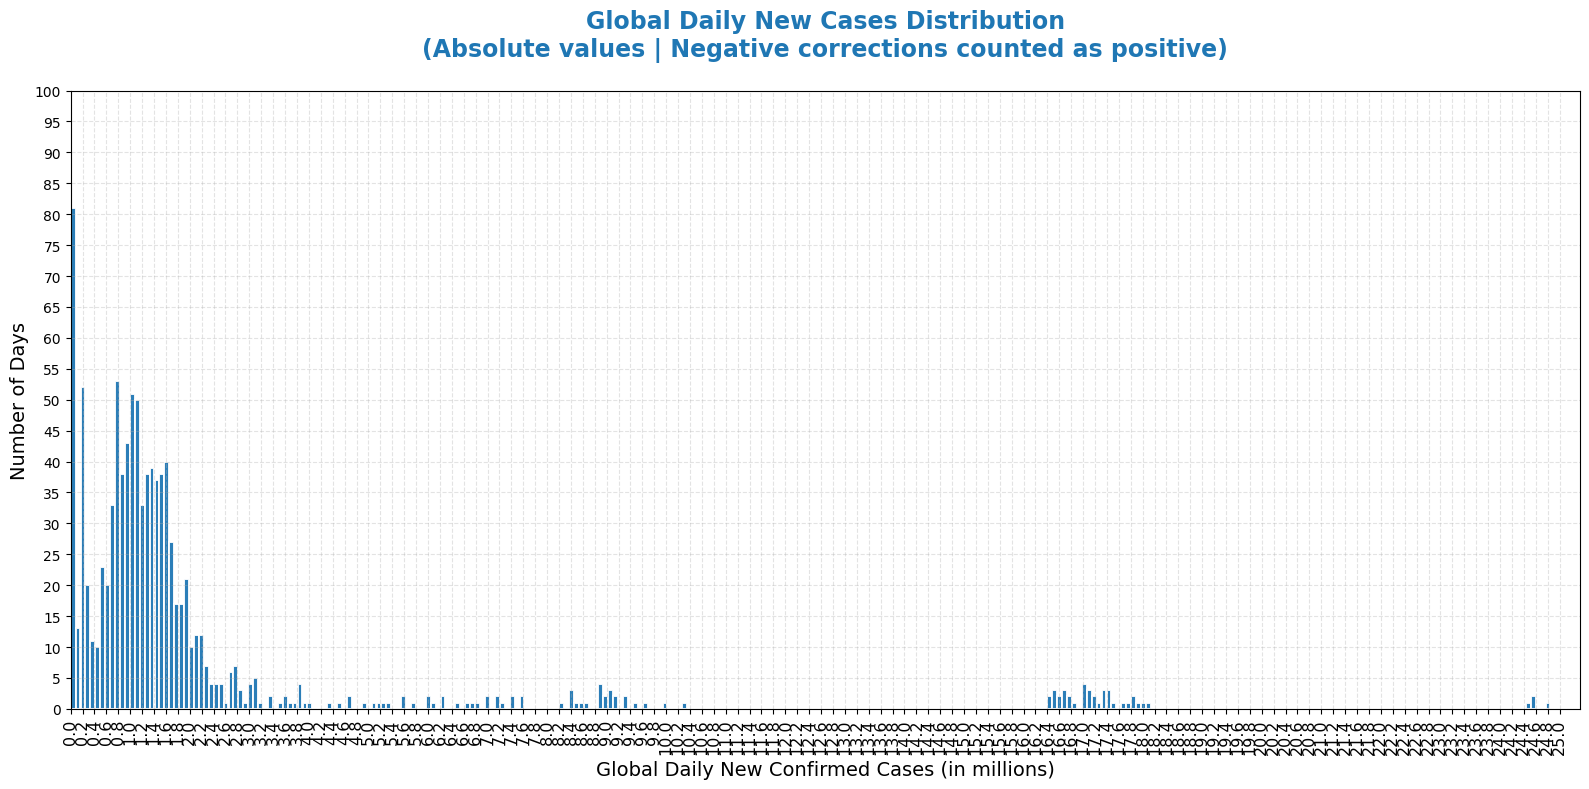

In [14]:
# Absolute-value global daily totals
daily_global_abs = (Epidemiology_df
                    .assign(new_confirmed_abs = Epidemiology_df['new_confirmed'].abs())
                    .groupby('date')['new_confirmed_abs']
                    .sum()
                    .astype(int))

plt.figure(figsize=(16, 8))

# KEY FIX: Use the actual data range instead of forcing 0 → max
data_in_millions = daily_global_abs / 1_000_000

plt.hist(data_in_millions,
         bins=300,                     # more bins = smoother curve
         color='#1f77b4',
         edgecolor='white',
         linewidth=1.4,
         alpha=0.95,
         rwidth=0.98)                  # removes gaps between bars

# X-axis: start exactly where the data starts (no artificial 0-padding)
plt.xlim(left=data_in_millions.min() * 0.95,   # tiny buffer on left
         right=data_in_millions.max() * 1.02)  # tiny buffer on right

# Clean 0.2 million ticks — no more weird gap!
xticks = np.arange(0, data_in_millions.max() + 0.2, 0.2)
plt.xticks(xticks, [f'{x:.1f}' for x in xticks],
           rotation=90, ha='center', va='top', fontsize=11.5)

# Y-axis: steps of 5, capped at 100
plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 5))

plt.xlabel('Global Daily New Confirmed Cases (in millions)', fontsize=14)
plt.ylabel('Number of Days', fontsize=14)
plt.title('Global Daily New Cases Distribution\n'
          '(Absolute values | Negative corrections counted as positive)',
          fontsize=17, fontweight='bold', color='#1f77b4', pad=25)

plt.grid(True, axis='both', alpha=0.35, linestyle='--', linewidth=0.8)
plt.subplots_adjust(bottom=0.20)
plt.tight_layout()
plt.show()

Univariate frequency graph for the Epidemiology dataset
Feature: new_deceased

Days with reported deaths : 978
Date range : 2020-01-02 to 2022-09-16
Peak daily deaths : 116,415.0 (116.4 thousand) on 2022-08-30
Median daily deaths : 16668
Mean daily deaths : 19300


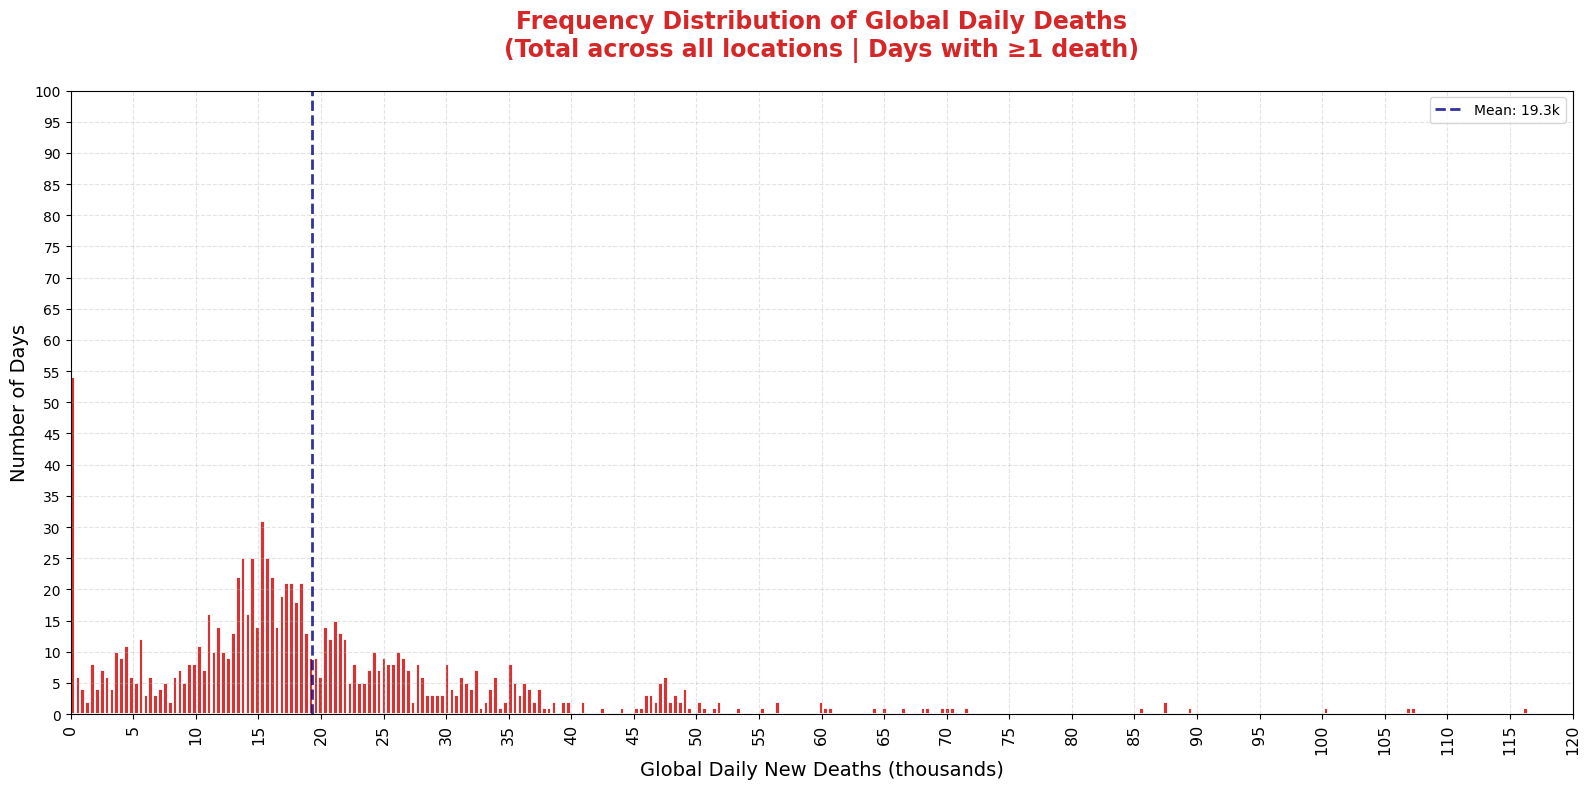

In [13]:
# === GLOBAL DAILY DEATHS — total across all locations each day ===
daily_deaths_abs = (Epidemiology_df
                    .assign(new_deceased_abs = Epidemiology_df['new_deceased'].abs())
                    .groupby('date')['new_deceased_abs']
                    .sum()  # Total deaths across all locations for each day
                    .astype(float)
                    )

# Filter out zeros and NaN values
daily_deaths_clean = daily_deaths_abs[daily_deaths_abs > 0].dropna()

# Convert to thousands for better x-axis
data_in_thousands = daily_deaths_clean / 1_000

print(f"Days with reported deaths : {len(daily_deaths_clean)}")
print(f"Date range : {daily_deaths_clean.index.min().date()} to {daily_deaths_clean.index.max().date()}")
print(f"Peak daily deaths : {daily_deaths_clean.max():,} ({daily_deaths_clean.max()/1000:.1f} thousand) on {daily_deaths_clean.idxmax().date()}")
print(f"Median daily deaths : {daily_deaths_clean.median():.0f}")
print(f"Mean daily deaths : {daily_deaths_clean.mean():.0f}")

plt.figure(figsize=(16, 8))

# Create histogram of daily global deaths
counts, bins, patches = plt.hist(data_in_thousands,
         bins=300,
         color='#d62728',
         edgecolor='white',
         linewidth=1.4,
         alpha=0.95,
         rwidth=0.98)

# Add vertical line at mean for reference
mean_thousands = data_in_thousands.mean()
plt.axvline(mean_thousands, color='navy', linestyle='--', linewidth=2, 
            alpha=0.8, label=f'Mean: {mean_thousands:.1f}k')

# X-axis configuration
plt.xlim(left=data_in_thousands.min() * 0.95,
         right=data_in_thousands.max() * 1.03)

# Clean ticks every 5 thousand deaths
xticks = np.arange(0, data_in_thousands.max() + 5, 5)
plt.xticks(xticks,
           [f'{x:.0f}' for x in xticks],
           rotation=90,
           ha='center',
           va='top',
           fontsize=11.5)

# Y-axis: steps of 5
plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 5))

plt.xlabel('Global Daily New Deaths (thousands)', fontsize=14)
plt.ylabel('Number of Days', fontsize=14)
plt.title('Frequency Distribution of Global Daily Deaths\n'
          '(Total across all locations | Days with ≥1 death)',
          fontsize=17, fontweight='bold', color='#d62728', pad=25)

plt.grid(True, axis='both', alpha=0.35, linestyle='--', linewidth=0.8)
plt.legend()
plt.subplots_adjust(bottom=0.20)
plt.tight_layout()
plt.show()

Univariate frequency graph for the Epidemiology dataset
Feature: new_recovered

Days with reported recoveries : 971
Peak daily recoveries         : 10,162,985.0 (10.16 million) on 2022-09-11


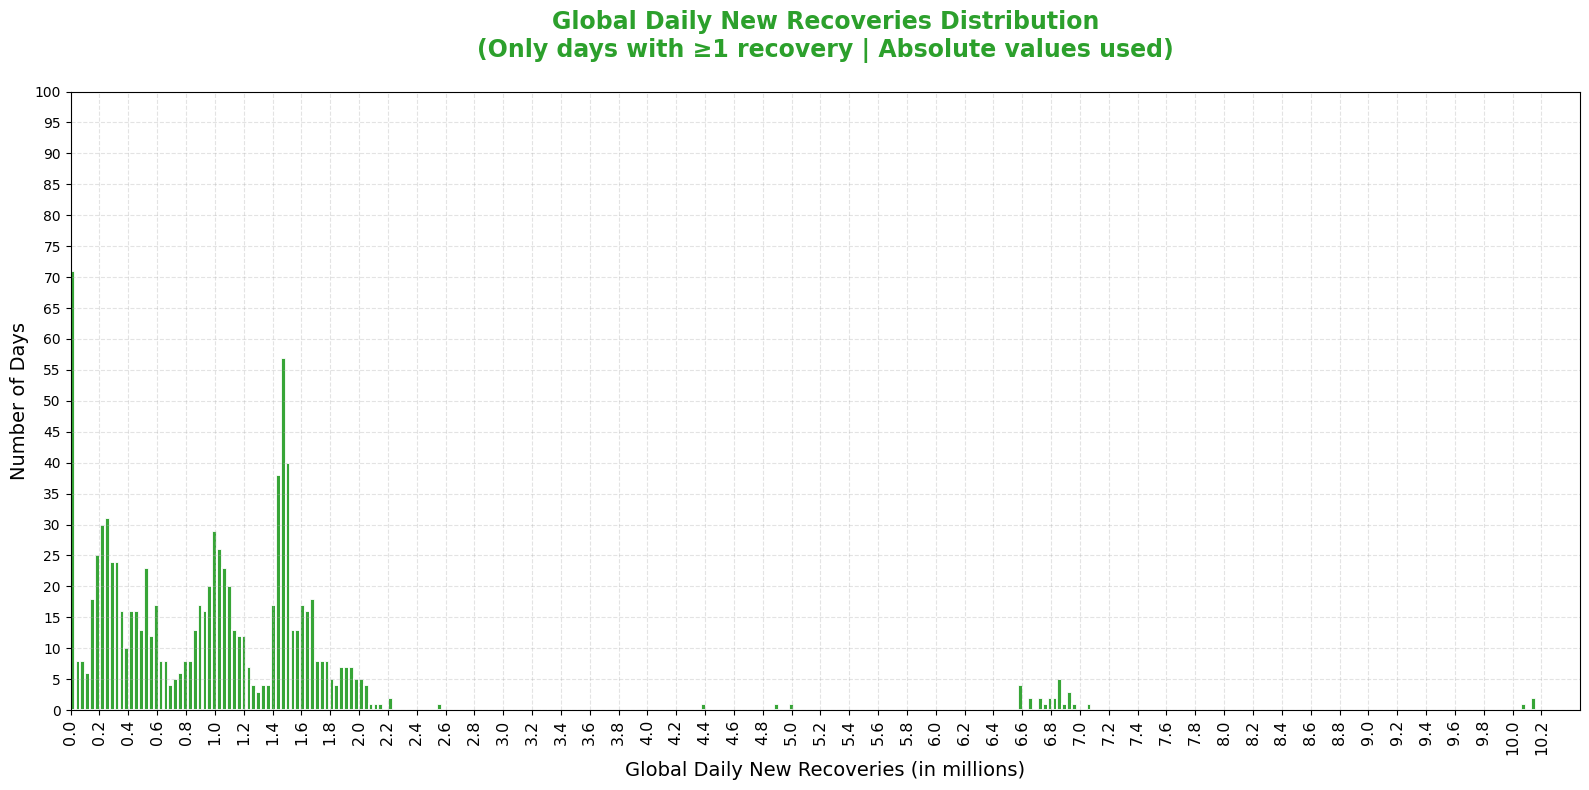

In [14]:
# === GLOBAL DAILY RECOVERIES — absolute values, ignoring zeros/NaN ===
daily_recovered_abs = (Epidemiology_df
                       .assign(new_recovered_abs = Epidemiology_df['new_recovered'].abs())
                       .groupby('date')['new_recovered_abs']
                       .sum()
                       .astype(float))

# Remove all days with zero or NaN recoveries
daily_recovered_clean = daily_recovered_abs[daily_recovered_abs > 0].dropna()

# Scale to millions for clean x-axis
data_in_millions = daily_recovered_clean / 1_000_000

print(f"Days with reported recoveries : {len(daily_recovered_clean)}")
print(f"Peak daily recoveries         : {daily_recovered_clean.max():,} "
      f"({data_in_millions.max():.2f} million) on {daily_recovered_clean.idxmax().date()}")

plt.figure(figsize=(16, 8))

plt.hist(data_in_millions,
         bins=300,
         color='#2ca02c',          # Green = recovery standard
         edgecolor='white',
         linewidth=1.4,
         alpha=0.95,
         rwidth=0.98)

# No empty gap — start right at first real recovery day
plt.xlim(left=data_in_millions.min() * 0.95,
         right=data_in_millions.max() * 1.03)

# X-axis: clean 0.2 million steps → 0.2, 0.4, 0.6, ..., 2.0 etc.
xticks = np.arange(0, data_in_millions.max() + 0.2, 0.2)
plt.xticks(xticks,
           [f'{x:.1f}' for x in xticks],
           rotation=90,
           ha='center',
           va='top',
           fontsize=11.5)

# Y-axis: steps of 5, cap at 100
plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 5))

plt.xlabel('Global Daily New Recoveries (in millions)', fontsize=14)
plt.ylabel('Number of Days', fontsize=14)
plt.title('Global Daily New Recoveries Distribution\n'
          '(Only days with ≥1 recovery | Absolute values used)',
          fontsize=17, fontweight='bold', color='#2ca02c', pad=25)

plt.grid(True, axis='both', alpha=0.35, linestyle='--', linewidth=0.8)
plt.subplots_adjust(bottom=0.20)
plt.tight_layout()
plt.show()

Univariate frequency graph for the Epidemiology dataset
Feature: new_tested

Days with testing reported   : 991
Maximum frequency observed   : 105 days
Peak daily tests             : 358,659,299 (358.7 million) on 2022-07-20


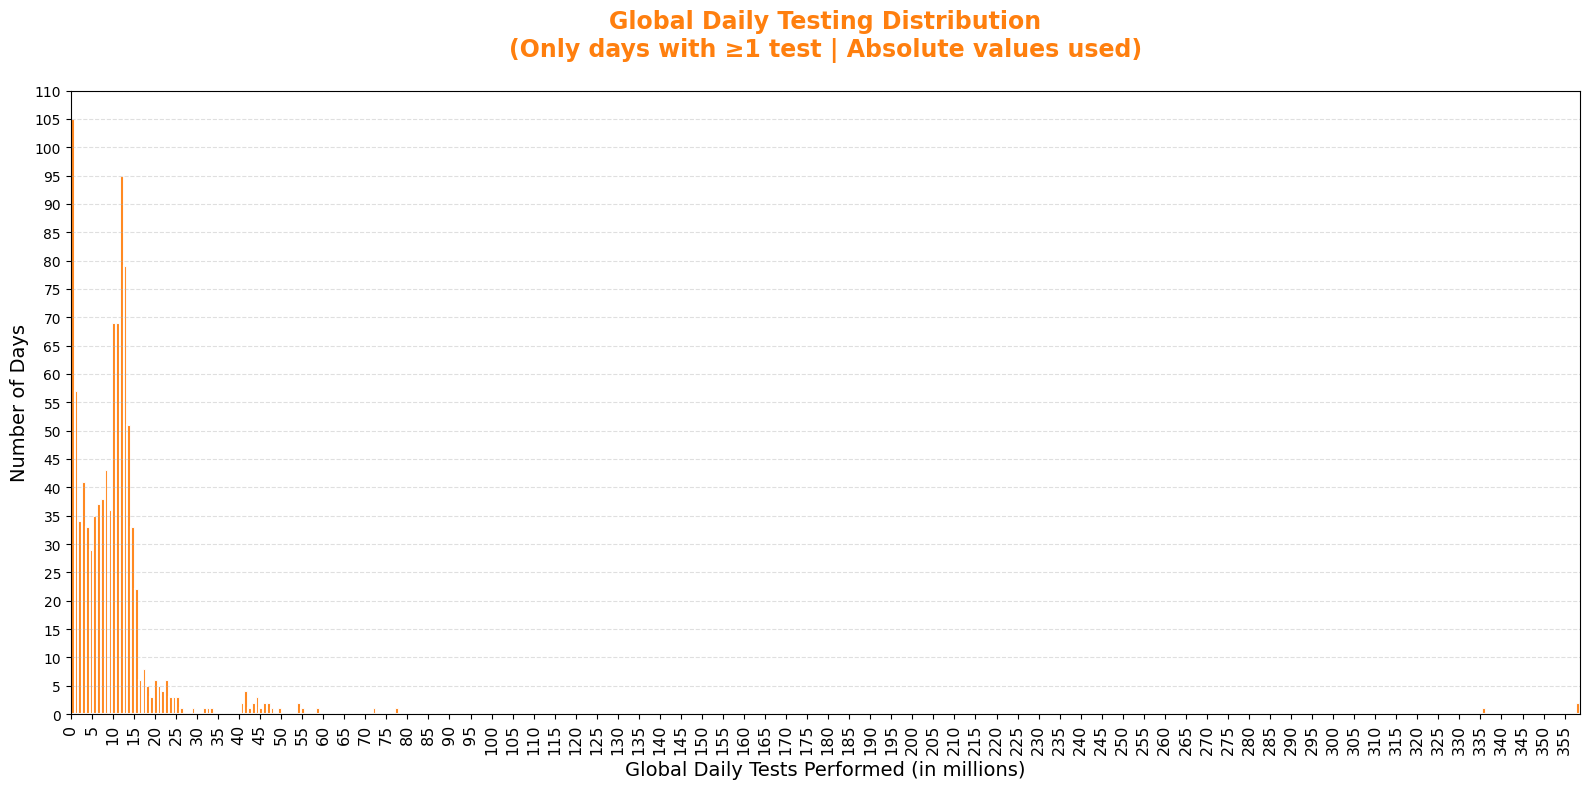

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# GLOBAL DAILY TESTS — absolute values, zeros & NaN removed
daily_tested_abs = (Epidemiology_df
                    .assign(new_tested_abs = Epidemiology_df['new_tested'].abs())
                    .groupby('date')['new_tested_abs']
                    .sum())

daily_tested_clean = daily_tested_abs[daily_tested_abs > 0].dropna().astype(int)
data_in_millions = daily_tested_clean / 1_000_000

print(f"Days with testing reported   : {len(daily_tested_clean)}")
print(f"Maximum frequency observed   : {np.histogram(data_in_millions, bins=400)[0].max()} days")
print(f"Peak daily tests             : {daily_tested_clean.max():,} "
      f"({data_in_millions.max():.1f} million) on {daily_tested_clean.idxmax().date()}")

plt.figure(figsize=(16, 8))

plt.hist(data_in_millions,
         bins=400,
         color='#ff7f0e',
         edgecolor='white',
         linewidth=1.5,
         alpha=0.96,
         rwidth=0.98)

# X-axis: 5-million steps
max_millions = data_in_millions.max()
xticks = np.arange(0, max_millions + 5, 5)
plt.xticks(xticks,
           [f'{x:.0f}' for x in xticks],
           rotation=90, ha='center', va='top', fontsize=11.5)

# Y-axis: capped at 110, steps of 5 → max observed frequency is 105
plt.ylim(0, 110)
plt.yticks(np.arange(0, 111, 5))

# REMOVE ALL SPACING around the plot — tight to axes
plt.margins(x=0, y=0)                    # ← removes space on left/right/bottom/top
plt.xlim(0, max_millions)                # start exactly at 0
plt.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.20)

plt.xlabel('Global Daily Tests Performed (in millions)', fontsize=14)
plt.ylabel('Number of Days', fontsize=14)
plt.title('Global Daily Testing Distribution\n'
          '(Only days with ≥1 test | Absolute values used)',
          fontsize=17, fontweight='bold', color='#ff7f0e', pad=25)

# Clean grid only on y-axis for clarity
plt.grid(True, axis='y', alpha=0.4, linestyle='--', linewidth=0.8)
plt.grid(False, axis='x')

plt.tight_layout()
plt.show()

multivariate time series analysis of:-
new_confirmed         
new_deceased          
new_recovered         
new_tested  

multivariate time series analysis of:-
 cumulative_confirmed         
 cumulative_deceased          
 cumulative_recovered         
 cumulative_tested  

Total days plotted: 32
Sample (should match your awk):
          date  new_confirmed  new_deceased  new_recovered  new_tested
0   2020-03-01         5660.0         119.0         2856.0     20886.0
30  2020-03-31       195071.0       13023.0        45380.0    593384.0
Plot also saved as high-res PNG: COVID_Daily_Every_Date.png


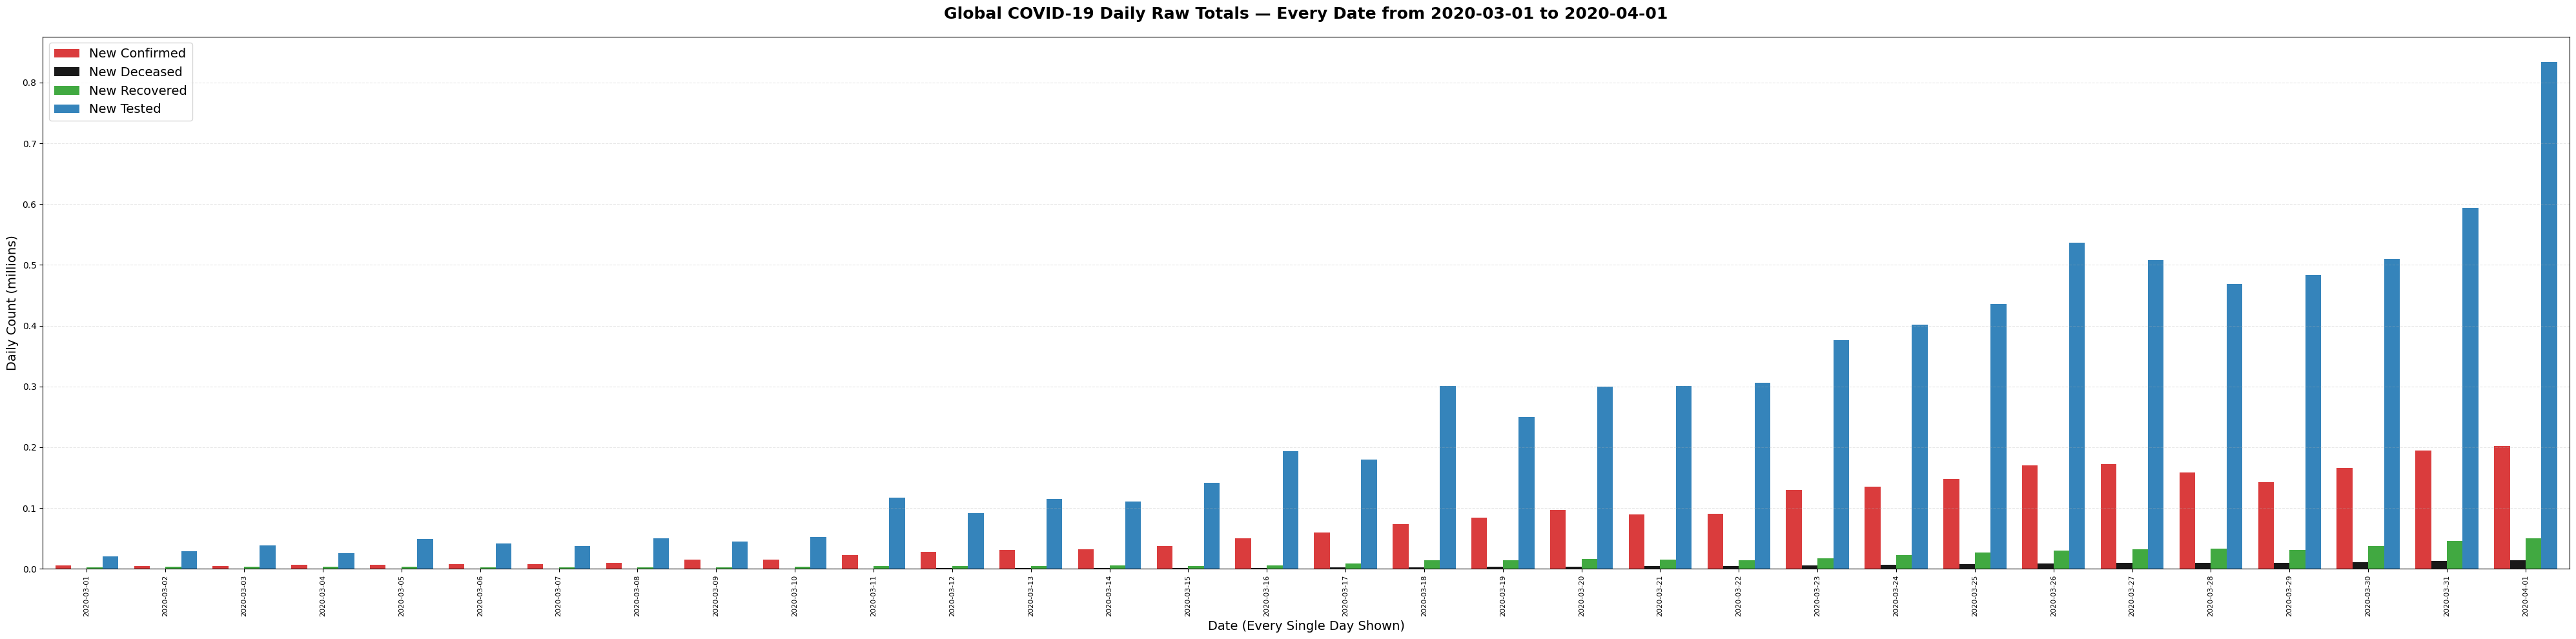

In [19]:

# ==================== USER SETTINGS ====================
start_date = '2020-03-01'
end_date   = '2020-04-01'
# ======================================================

# 1. Load only needed columns + parse dates correctly
cols = ['date', 'new_confirmed', 'new_deceased', 'new_recovered', 'new_tested']
df = pd.read_csv('D:/Datasets/Pandemic datasets/google health data/epidemiology.csv', usecols=cols, parse_dates=['date'])

# 2. Remove time part & timezone — force pure date
df['date'] = df['date'].dt.date

# 3. Fill NaN with 0 (exactly like awk)
df[cols[1:]] = df[cols[1:]].fillna(0)

# 4. Filter date range
df = df[(df['date'] >= pd.to_datetime(start_date).date()) &
        (df['date'] <= pd.to_datetime(end_date).date())].copy()

# 5. Group by date and sum — 100% accurate
daily = (df.groupby('date', as_index=False)
         .agg({'new_confirmed':'sum',
               'new_deceased':'sum',
               'new_recovered':'sum',
               'new_tested':'sum'})
         .sort_values('date')
         .reset_index(drop=True))

print(f"Total days plotted: {len(daily)}")
print("Sample (should match your awk):")
print(daily[daily['date'].isin([pd.to_datetime(d).date() for d in ['2020-03-01','2020-03-31','2020-04-30']])])

# 6. Convert to millions
daily_millions = daily.copy()
for c in cols[1:]:
    daily_millions[c] = daily_millions[c] / 1_000_000

# 7. PLOT — EVERY SINGLE DATE ON X-AXIS
plt.figure(figsize=(40, 10))   # Very wide to fit all labels

bar_width = 0.2
x = np.arange(len(daily_millions))

plt.bar(x - 1.5*bar_width, daily_millions['new_confirmed'], bar_width,
        label='New Confirmed', color='#d62728', alpha=0.9)
plt.bar(x - 0.5*bar_width, daily_millions['new_deceased'],   bar_width,
        label='New Deceased',   color='black',      alpha=0.9)
plt.bar(x + 0.5*bar_width, daily_millions['new_recovered'], bar_width,
        label='New Recovered',  color='#2ca02c',    alpha=0.9)
plt.bar(x + 1.5*bar_width, daily_millions['new_tested'],    bar_width,
        label='New Tested',     color='#1f77b4',    alpha=0.9)

# THIS IS THE KEY: Show EVERY date
plt.xticks(
    ticks=x,
    labels=[d.strftime('%Y-%m-%d') for d in daily_millions['date']],
    rotation=90,
    fontsize=8,
    ha='center'
)

plt.xlabel('Date (Every Single Day Shown)', fontsize=14)
plt.ylabel('Daily Count (millions)', fontsize=14)
plt.title(f'Global COVID-19 Daily Raw Totals — Every Date from {start_date} to {end_date}',
          fontsize=18, fontweight='bold', pad=20)
plt.legend(fontsize=14, loc='upper left')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.margins(x=0.005)
plt.tight_layout()

# Optional: Save as high-res image (because screen might cut off)
plt.savefig('COVID_Daily_Every_Date.png', dpi=300, bbox_inches='tight')
print("Plot also saved as high-res PNG: COVID_Daily_Every_Date.png")

plt.show()

multivariate time series analysis of:-
 cumulative_confirmed         
 cumulative_deceased          
 cumulative_recovered         
 cumulative_tested  

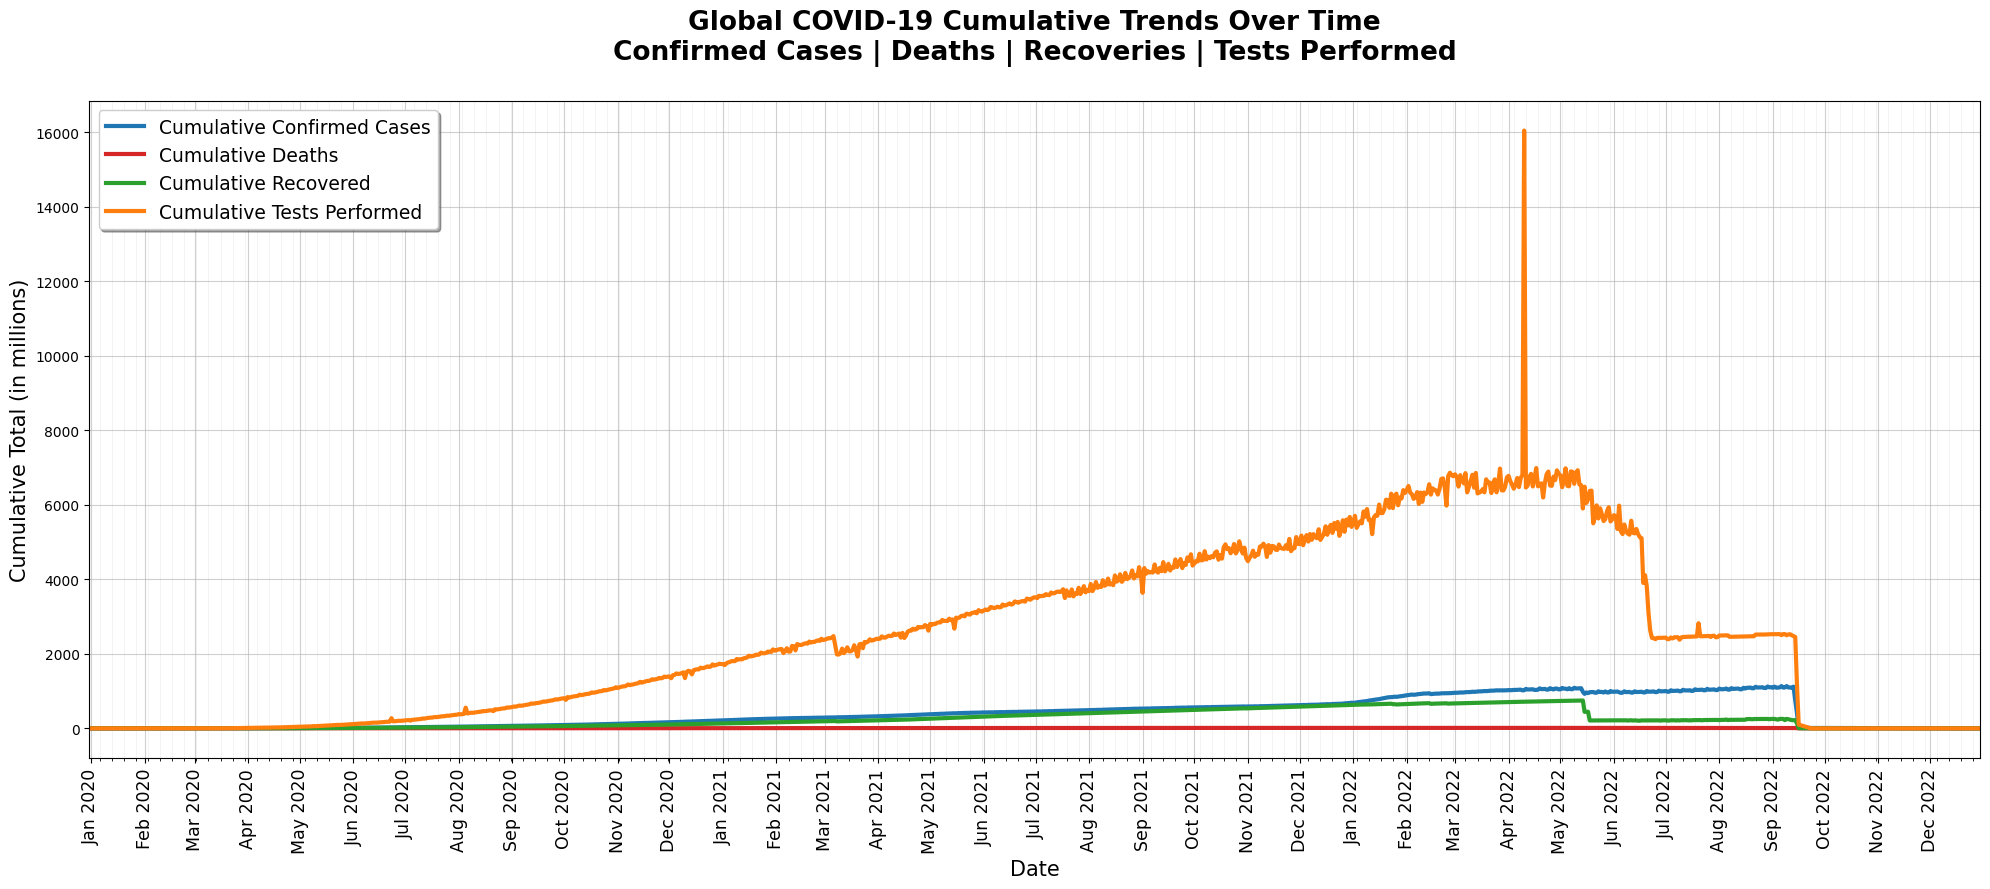

In [20]:
from matplotlib.dates import DateFormatter, WeekdayLocator, MonthLocator

# === GLOBAL CUMULATIVE DATA ===
cumulative = (Epidemiology_df
              .groupby('date')[['cumulative_confirmed', 
                                'cumulative_deceased', 
                                'cumulative_recovered', 
                                'cumulative_tested']]
              .sum())

cumulative.index = pd.to_datetime(cumulative.index)
cumulative = cumulative.ffill().fillna(0)

plt.figure(figsize=(20, 9))

# Plot lines (in millions)
plt.plot(cumulative.index, cumulative['cumulative_confirmed'] / 1e6,
         label='Cumulative Confirmed Cases', color='#1f77b4', linewidth=3)

plt.plot(cumulative.index, cumulative['cumulative_deceased'] / 1e6,
         label='Cumulative Deaths', color='#d62728', linewidth=3)

plt.plot(cumulative.index, cumulative['cumulative_recovered'] / 1e6,
         label='Cumulative Recovered', color='#2ca02c', linewidth=3)

plt.plot(cumulative.index, cumulative['cumulative_tested'] / 1e6,
         label='Cumulative Tests Performed', color='#ff7f0e', linewidth=3)

# === GRANULAR + VERTICAL X-AXIS LABELS ===
ax = plt.gca()

# Major ticks: 1st of each month
ax.xaxis.set_major_locator(MonthLocator(bymonthday=1))
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))   # Jan 2020, Feb 2020, etc.

# Minor ticks: every Monday (no labels)
ax.xaxis.set_minor_locator(WeekdayLocator(byweekday=0))

# VERTICAL LABELS — fully readable
plt.xticks(rotation=90, ha='center', va='top', fontsize=12.5)

# Grid
plt.grid(True, which='major', alpha=0.6, linestyle='-', linewidth=0.8)
plt.grid(True, which='minor', alpha=0.2, linestyle='-', linewidth=0.5)

# Labels & legend
plt.xlabel('Date', fontsize=15)
plt.ylabel('Cumulative Total (in millions)', fontsize=15)
plt.title('Global COVID-19 Cumulative Trends Over Time\n'
          'Confirmed Cases | Deaths | Recoveries | Tests Performed',
          fontsize=19, fontweight='bold', pad=30)

plt.legend(fontsize=13.5, loc='upper left', frameon=True, fancybox=True, shadow=True)

# Final layout — extra bottom space for vertical labels
plt.margins(x=0)
plt.subplots_adjust(left=0.06, right=0.98, top=0.90, bottom=0.22)  # ← more room at bottom
plt.tight_layout()
plt.show()

Geospatial and heatmap analysis of new cases or infections throughout the entire world

In [22]:
import plotly.express as px

# === DATA PREP (same as before) ===
spatial_summary = (Epidemiology_df
                   .merge(location_df[['location_key', 'latitude', 'longitude']], 
                          on='location_key', how='inner')
                   .query('latitude == latitude and longitude == longitude')
                   .query('new_confirmed > 0')
                   .groupby(['location_key', 'latitude', 'longitude'], as_index=False)
                   ['new_confirmed'].sum())

# === FINAL PERFECT MAP – BLACK BORDERS + CLASSIC STYLE ===
fig = px.scatter_geo(
    spatial_summary,
    lat='latitude',
    lon='longitude',
    size='new_confirmed',
    hover_name='location_key',
    hover_data={'new_confirmed': ':,'},
    color='new_confirmed',
    color_continuous_scale='Reds',
    size_max=90,
    projection="natural earth",
    title="<b>Global COVID-19 Pandemic – Total Confirmed Cases by Location</b>"
)

fig.update_layout(
    title_font_size=24,
    title_x=0.5,

    # THE KEY: THIS MAKES BORDERS, COASTLINES & GLOBE EDGE BLACK AND VISIBLE
    geo=dict(
        showframe=True,                    # Show the globe border
        framecolor="#2F4F4F",                # Black globe edge
        framewidth=3,

        showcoastlines=True,
        coastlinecolor="#2F4F4F",            # Black coastlines
        coastlinewidth=1.3,

        showland=True,
        landcolor="white",               # Light beige (like classic maps)

        showocean=True,
        oceancolor="#a3c9e2",              # Natural blue ocean

        showlakes=True,
        lakecolor="#a3c9e2",

        showcountries=True,
        countrycolor="#2F4F4F",              # Black country borders
        countrywidth=1.2,

        showsubunits=True,
        subunitcolor="white",              # Black state/province borders
        subunitwidth=0.7,
    ),

    coloraxis_colorbar=dict(
        title="Total Cases",
        tickformat=',',
        x=0.02,
        len=0.7
    ),

    height=850,
    margin=dict(l=0, r=0, t=80, b=0),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

# === SHOW & SAVE ===
fig.show(renderer="browser")  # Opens perfectly in your browser
fig.write_html("Global_COVID_Map_Black_Borders_Final.html")

print("DONE! Your perfect map with BLACK borders, coastlines, and globe edge is ready.")
print("File saved: Global_COVID_Map_Black_Borders_Final.html")

DONE! Your perfect map with BLACK borders, coastlines, and globe edge is ready.
File saved: Global_COVID_Map_Black_Borders_Final.html


Multivariate Correlation matrix for independent variables 
new_tested, new_confirmed, new_recovered and new_deceased

Correlation Matrix:
               new_confirmed  new_deceased  new_recovered  new_tested
new_confirmed       1.000000      0.412490       0.154626    0.075220
new_deceased        0.412490      1.000000       0.827829    0.018129
new_recovered       0.154626      0.827829       1.000000    0.006801
new_tested          0.075220      0.018129       0.006801    1.000000


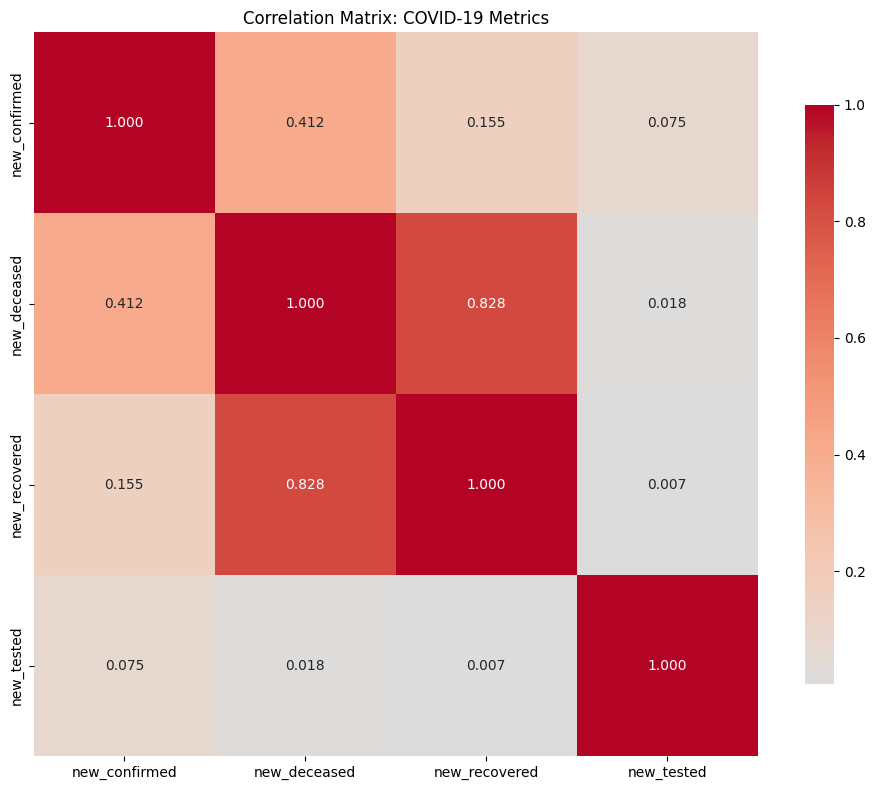


Pairplot to visualize relationships:


MemoryError: Unable to allocate 812. MiB for an array with shape (1, 106397820) and data type int64

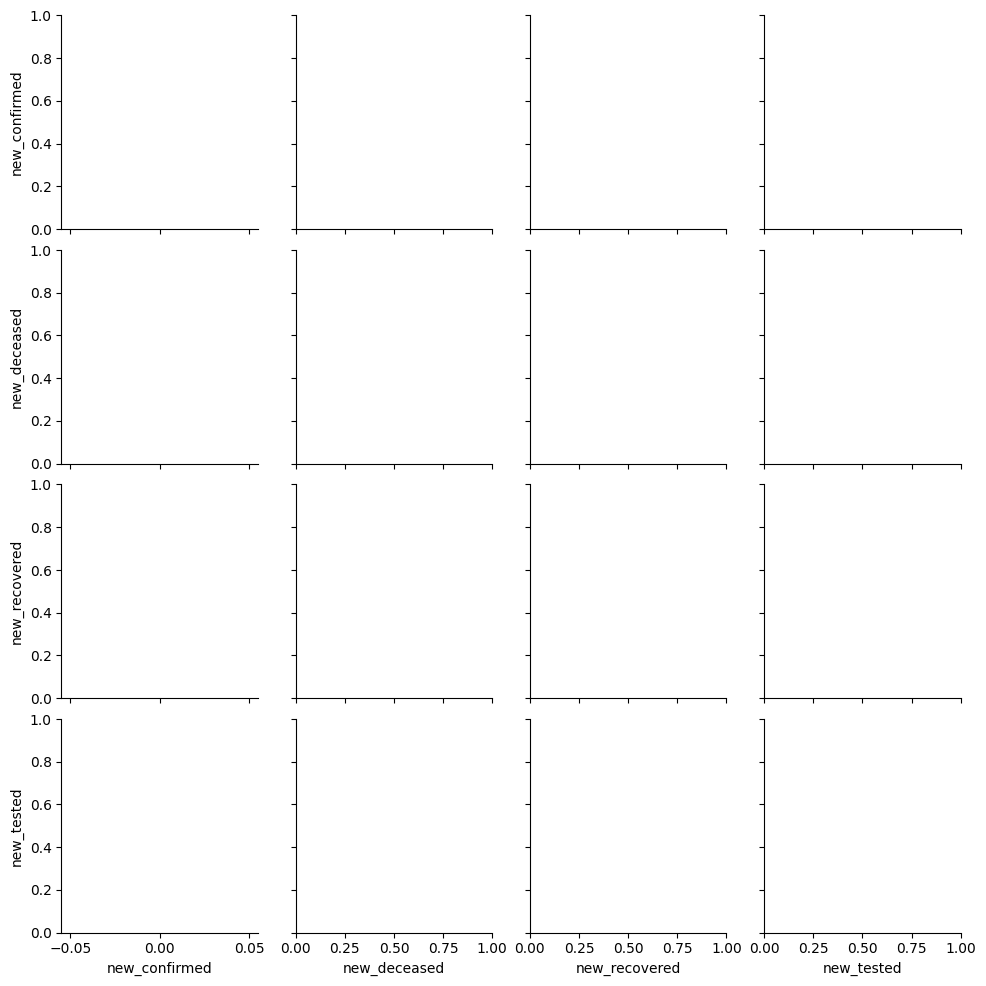

In [23]:
# Assuming you have a DataFrame called 'df' with your COVID-19 data
# If not, you can load your data like this:
# df = pd.read_csv('your_covid_data.csv')

# Select only the columns we're interested in
covid_metrics = Epidemiology_df[['new_confirmed', 'new_deceased', 'new_recovered', 'new_tested']]

# Calculate the correlation matrix
correlation_matrix = covid_metrics.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Create a heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix: COVID-19 Metrics')
plt.tight_layout()
plt.show()

# Alternative: Using a more detailed visualization with seaborn pairplot
print("\nPairplot to visualize relationships:")
sns.pairplot(covid_metrics)
plt.suptitle('Pairplot of COVID-19 Metrics', y=1.02)
plt.show()

Outlier analysis for below features
new_confirmed
new_deceased
new_recovered
new_tested

OUTLIER ANALYSIS FOR COVID-19 METRICS
Total days in dataset: 37

OUTLIER ANALYSIS RESULTS:

--- Confirmed Cases (new_confirmed) ---
Total: 17,052,970
Mean: 460891.08
Median: 461085.00
Std Dev: 615.77
Min: 459,433
Max: 461,870

IQR Method:
  Q1: 460517.00
  Q3: 461283.00
  IQR: 3064.00
  Lower bound: 459368.00
  Upper bound: 462432.00
  Outliers detected: 0
Z-score Method:
  Outliers detected: 0

--- Deaths (new_deceased) ---
Total: 341,104
Mean: 9219.03
Median: 9228.00
Std Dev: 84.08
Min: 8,992
Max: 9,389

IQR Method:
  Q1: 9183.00
  Q3: 9267.00
  IQR: 336.00
  Lower bound: 9057.00
  Upper bound: 9393.00
  Outliers detected: 2
Z-score Method:
  Outliers detected: 0

--- Recoveries (new_recovered) ---
Total: 13,640,344
Mean: 368657.95
Median: 368838.00
Std Dev: 787.75
Min: 366,588
Max: 370,190

IQR Method:
  Q1: 368236.00
  Q3: 369106.00
  IQR: 3480.00
  Lower bound: 366931.00
  Upper bound: 370411.00
  Outliers detected: 1
Z-score Method:
  Outliers detected: 0

--- Tests (new_tested) 

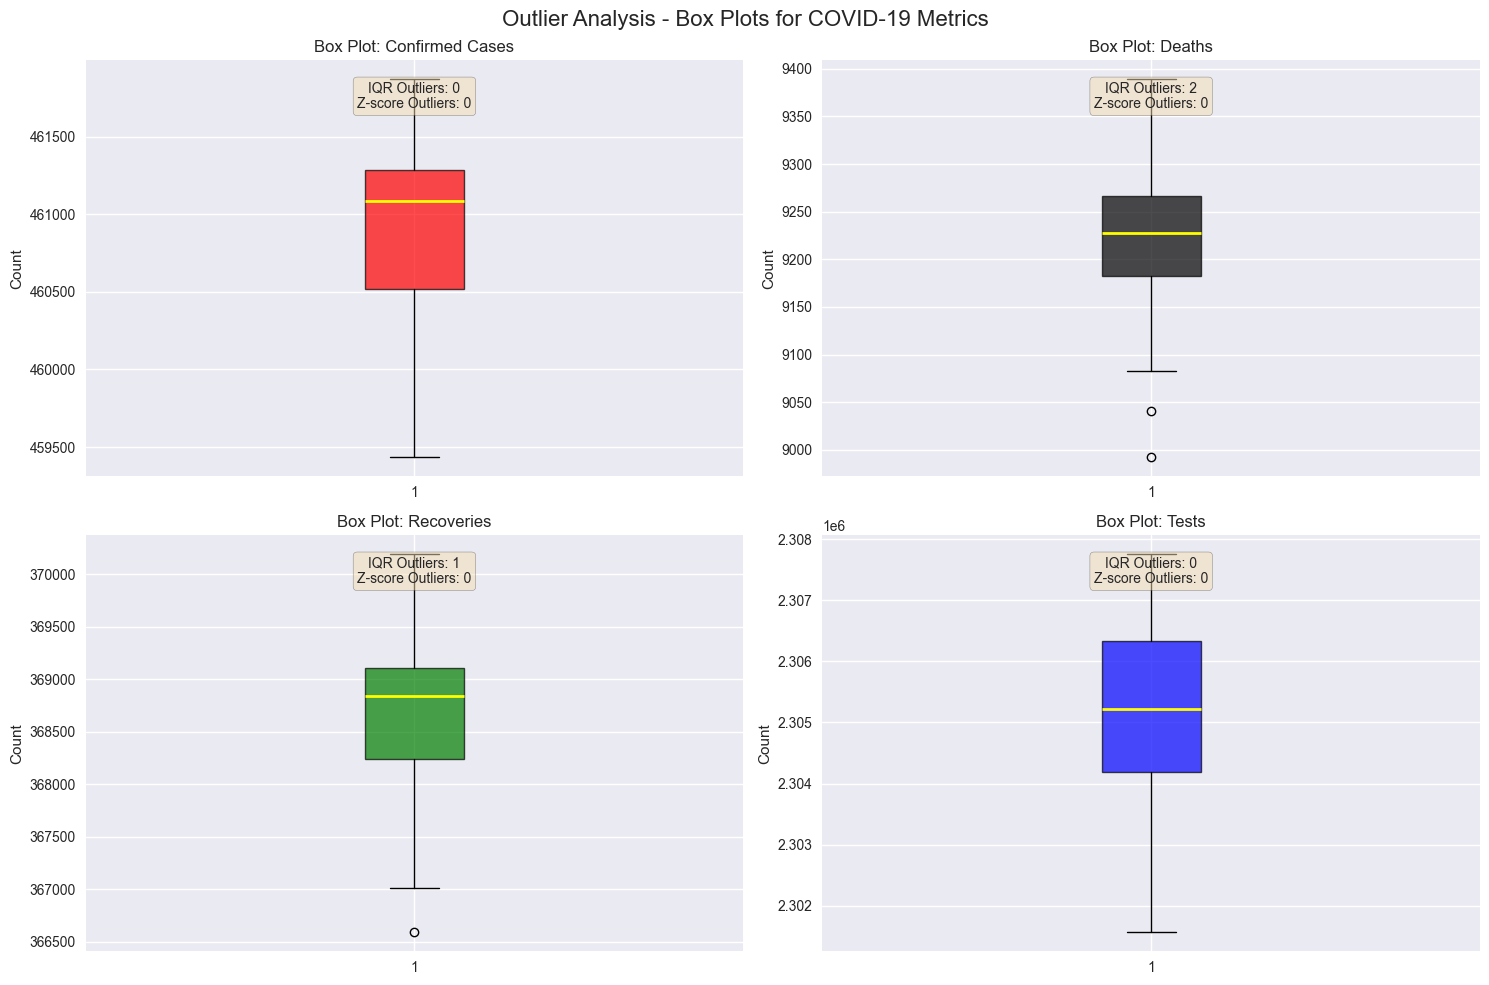

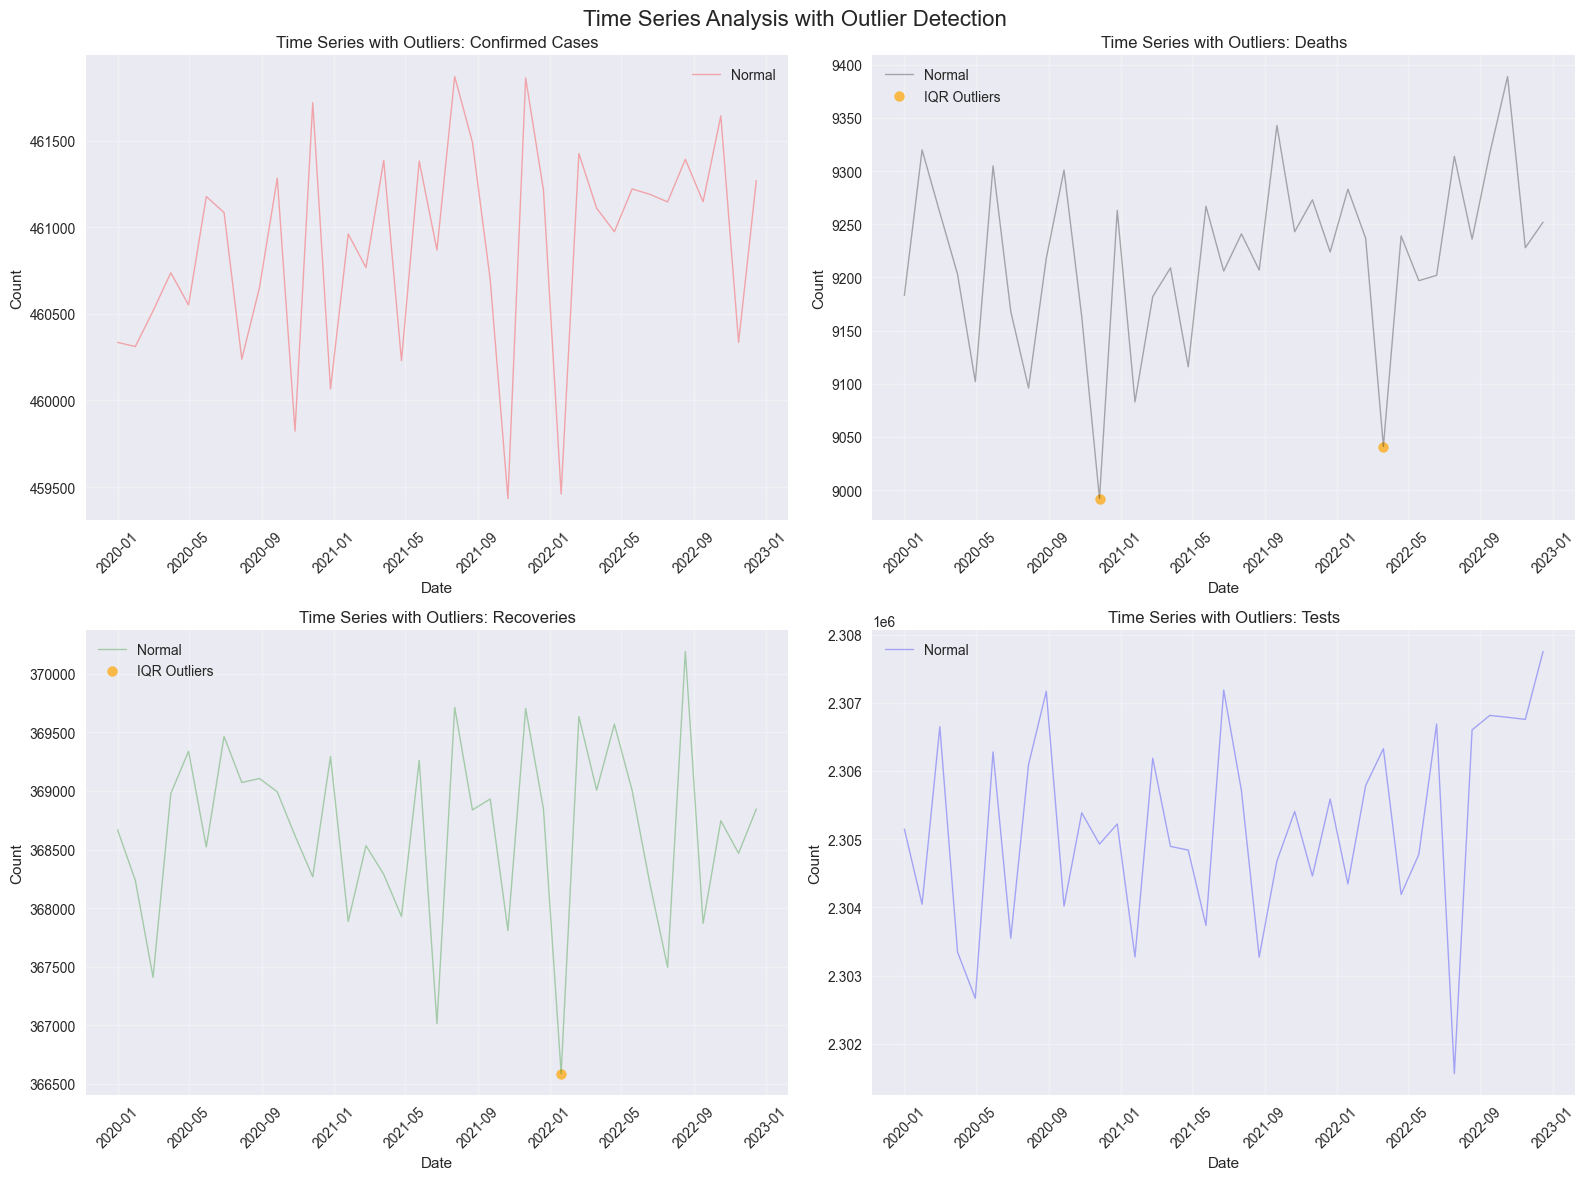

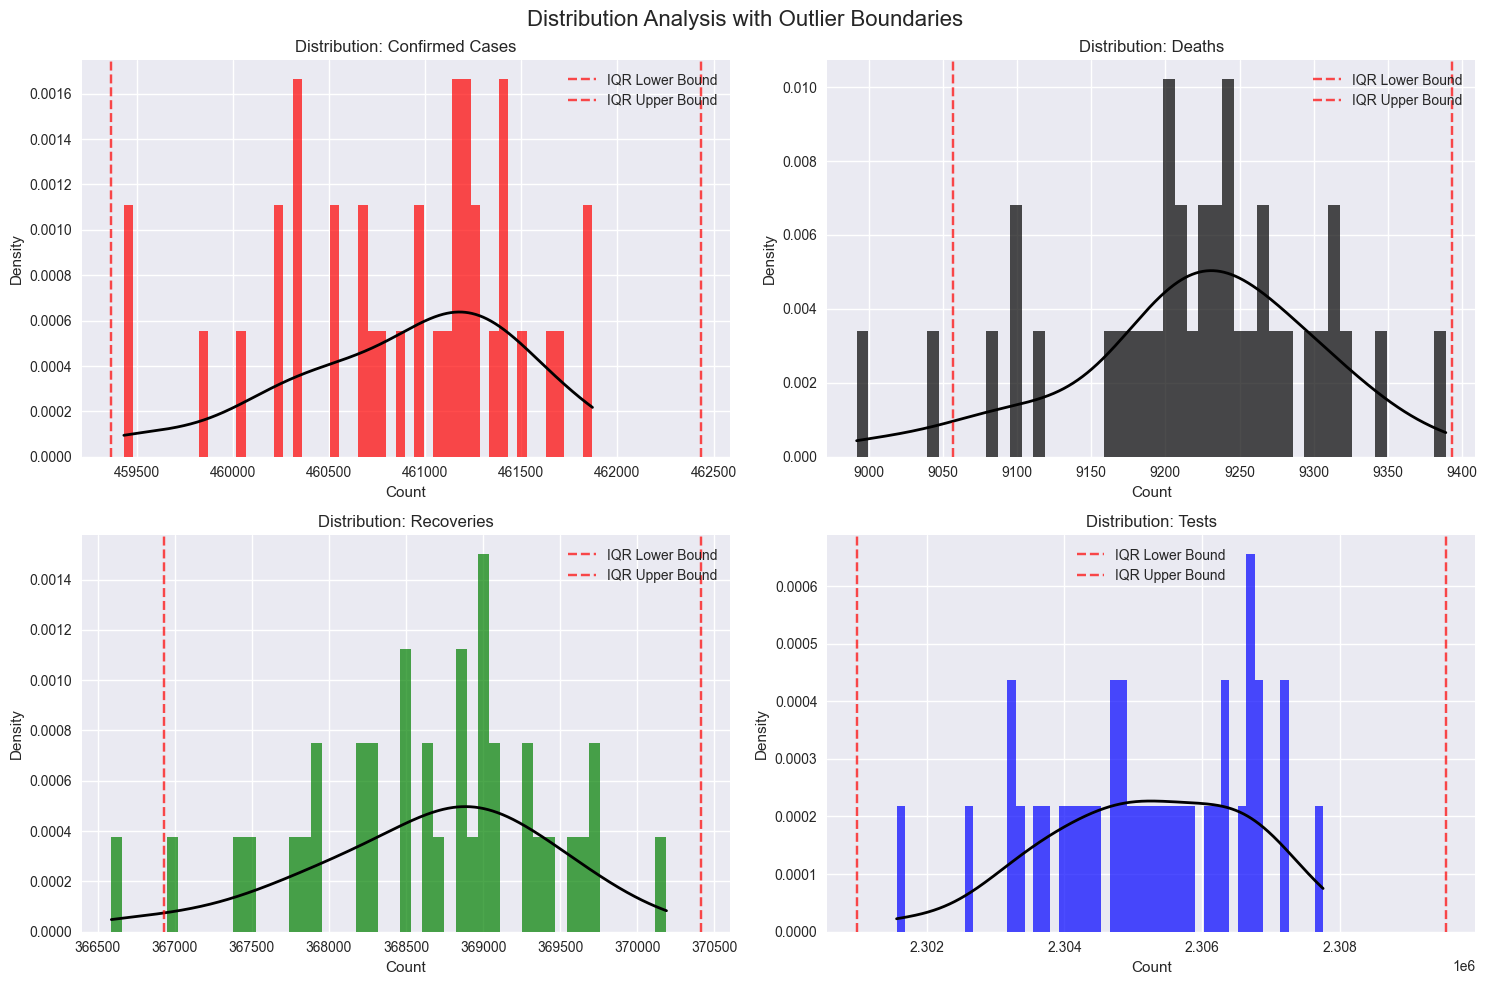

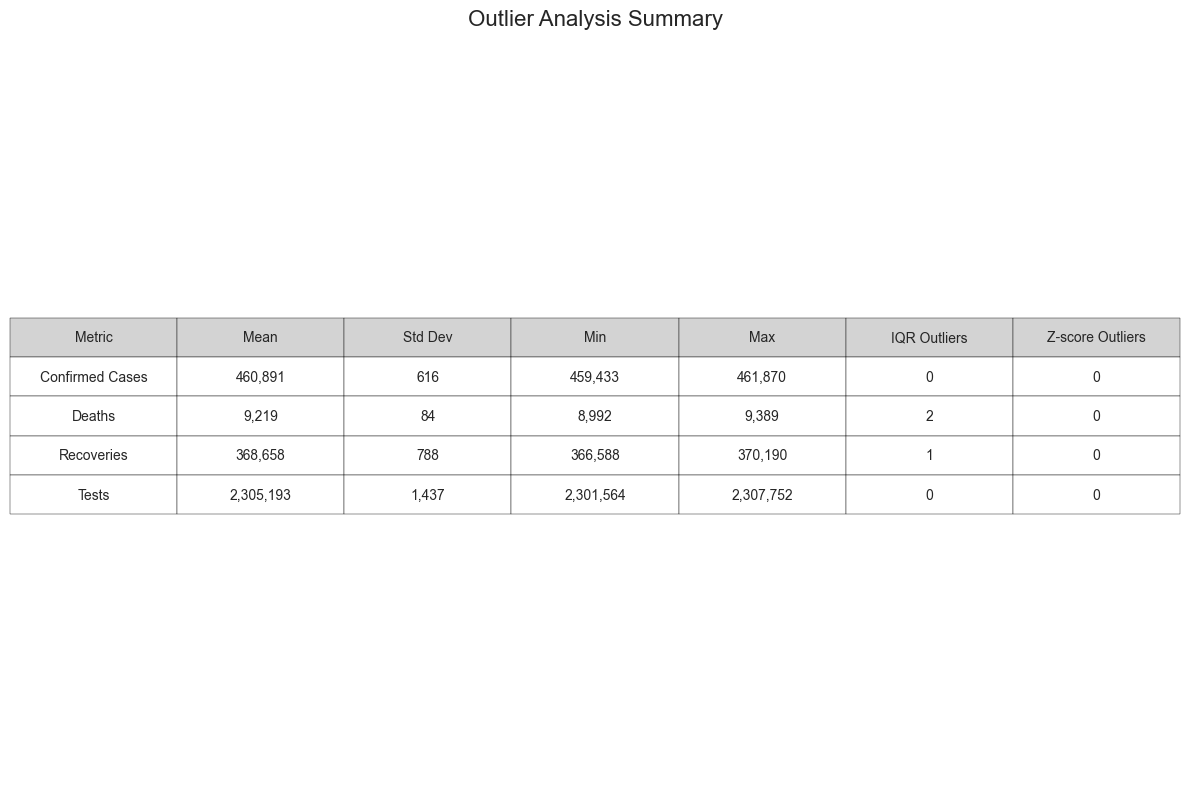


DETAILED OUTLIER INFORMATION

🔴 Confirmed Cases - Significant Outliers:
----------------------------------------
No common outliers detected by both methods

🔴 Deaths - Significant Outliers:
----------------------------------------
No common outliers detected by both methods

Top 3 IQR outliers:
  2022-03-21: 9,041
  2020-11-26: 8,992

🔴 Recoveries - Significant Outliers:
----------------------------------------
No common outliers detected by both methods

Top 3 IQR outliers:
  2022-01-20: 366,588

🔴 Tests - Significant Outliers:
----------------------------------------
No common outliers detected by both methods

TREND ANALYSIS (WITHOUT OUTLIERS)

📈 Confirmed Cases:
  Original mean: 460,891.08
  Clean mean (no outliers): 460,891.08
  Change: +0.0%
  Original volatility: 615.77
  Clean volatility: 615.77
  Volatility change: +0.0%

📈 Deaths:
  Original mean: 9,219.03
  Clean mean (no outliers): 9,230.60
  Change: +0.1%
  Original volatility: 84.08
  Clean volatility: 69.99
  Volatilit

In [41]:
import scipy.stats as stats
from scipy import stats

print("OUTLIER ANALYSIS FOR COVID-19 METRICS")
print("="*50)

# Calculate daily totals across all locations
daily_totals = epidemiology_df.groupby('date').agg({
    'new_confirmed': 'sum',
    'new_deceased': 'sum',
    'new_recovered': 'sum',
    'new_tested': 'sum'
}).reset_index()

print(f"Total days in dataset: {len(daily_totals)}")

# Define metrics and colors
metrics = ['new_confirmed', 'new_deceased', 'new_recovered', 'new_tested']
colors = ['red', 'black', 'green', 'blue']
names = ['Confirmed Cases', 'Deaths', 'Recoveries', 'Tests']

# Function to detect outliers using IQR method
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Function to detect outliers using Z-score method
def detect_outliers_zscore(data, feature, threshold=3):
    z_scores = np.abs(stats.zscore(data[feature]))
    outliers = data[z_scores > threshold]
    return outliers

# Perform outlier analysis for each metric
print("\nOUTLIER ANALYSIS RESULTS:")
print("="*50)

outlier_summary = {}

for metric, color, name in zip(metrics, colors, names):
    print(f"\n--- {name} ({metric}) ---")
    
    # Basic statistics
    data = daily_totals[metric]
    print(f"Total: {data.sum():,}")
    print(f"Mean: {data.mean():.2f}")
    print(f"Median: {data.median():.2f}")
    print(f"Std Dev: {data.std():.2f}")
    print(f"Min: {data.min():,}")
    print(f"Max: {data.max():,}")
    
    # IQR method
    iqr_outliers, lower_bound, upper_bound = detect_outliers_iqr(daily_totals, metric)
    print(f"\nIQR Method:")
    print(f"  Q1: {daily_totals[metric].quantile(0.25):.2f}")
    print(f"  Q3: {daily_totals[metric].quantile(0.75):.2f}")
    print(f"  IQR: {upper_bound - lower_bound:.2f}")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")
    print(f"  Outliers detected: {len(iqr_outliers)}")
    
    # Z-score method
    zscore_outliers = detect_outliers_zscore(daily_totals, metric)
    print(f"Z-score Method:")
    print(f"  Outliers detected: {len(zscore_outliers)}")
    
    # Store results
    outlier_summary[metric] = {
        'iqr_outliers': iqr_outliers,
        'zscore_outliers': zscore_outliers,
        'stats': {
            'mean': data.mean(),
            'std': data.std(),
            'min': data.min(),
            'max': data.max()
        }
    }

# Create visualization 1: Box plots for each metric
plt.figure(figsize=(15, 10))

for i, (metric, color, name) in enumerate(zip(metrics, colors, names), 1):
    plt.subplot(2, 2, i)
    plt.boxplot(daily_totals[metric], patch_artist=True, 
                boxprops=dict(facecolor=color, alpha=0.7),
                medianprops=dict(color='yellow', linewidth=2))
    plt.title(f'Box Plot: {name}')
    plt.ylabel('Count')
    
    # Add outlier information
    iqr_count = len(outlier_summary[metric]['iqr_outliers'])
    z_count = len(outlier_summary[metric]['zscore_outliers'])
    plt.text(0.5, 0.95, f'IQR Outliers: {iqr_count}\nZ-score Outliers: {z_count}', 
             transform=plt.gca().transAxes, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Outlier Analysis - Box Plots for COVID-19 Metrics', fontsize=16)
plt.tight_layout()
plt.show()

# Create visualization 2: Time series with outliers highlighted
plt.figure(figsize=(16, 12))

for i, (metric, color, name) in enumerate(zip(metrics, colors, names), 1):
    plt.subplot(2, 2, i)
    
    # Plot all data points
    plt.plot(daily_totals['date'], daily_totals[metric], 
             color=color, alpha=0.3, linewidth=1, label='Normal')
    
    # Highlight IQR outliers
    iqr_outliers = outlier_summary[metric]['iqr_outliers']
    if len(iqr_outliers) > 0:
        plt.scatter(iqr_outliers['date'], iqr_outliers[metric], 
                   color='orange', s=50, label='IQR Outliers', alpha=0.7)
    
    # Highlight Z-score outliers
    z_outliers = outlier_summary[metric]['zscore_outliers']
    if len(z_outliers) > 0:
        plt.scatter(z_outliers['date'], z_outliers[metric], 
                   color='red', s=80, marker='x', label='Z-score Outliers', linewidth=2)
    
    plt.title(f'Time Series with Outliers: {name}')
    plt.xlabel('Date')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

plt.suptitle('Time Series Analysis with Outlier Detection', fontsize=16)
plt.tight_layout()
plt.show()

# Create visualization 3: Distribution plots with outlier boundaries
plt.figure(figsize=(15, 10))

for i, (metric, color, name) in enumerate(zip(metrics, colors, names), 1):
    plt.subplot(2, 2, i)
    
    data = daily_totals[metric]
    
    # Plot histogram
    n, bins, patches = plt.hist(data, bins=50, alpha=0.7, color=color, density=True)
    
    # Add density curve
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 1000)
    plt.plot(x_range, kde(x_range), 'black', linewidth=2)
    
    # Mark outlier boundaries (IQR method)
    _, lower_bound, upper_bound = detect_outliers_iqr(daily_totals, metric)
    plt.axvline(lower_bound, color='red', linestyle='--', alpha=0.7, label='IQR Lower Bound')
    plt.axvline(upper_bound, color='red', linestyle='--', alpha=0.7, label='IQR Upper Bound')
    
    plt.title(f'Distribution: {name}')
    plt.xlabel('Count')
    plt.ylabel('Density')
    plt.legend()

plt.suptitle('Distribution Analysis with Outlier Boundaries', fontsize=16)
plt.tight_layout()
plt.show()

# Create visualization 4: Summary statistics and outlier table
plt.figure(figsize=(12, 8))

# Create a table with summary statistics
summary_data = []
for metric, name in zip(metrics, names):
    stats = outlier_summary[metric]['stats']
    iqr_count = len(outlier_summary[metric]['iqr_outliers'])
    z_count = len(outlier_summary[metric]['zscore_outliers'])
    
    summary_data.append([
        name,
        f"{stats['mean']:,.0f}",
        f"{stats['std']:,.0f}",
        f"{stats['min']:,}",
        f"{stats['max']:,}",
        f"{iqr_count}",
        f"{z_count}"
    ])

# Create table
table = plt.table(cellText=summary_data,
                  colLabels=['Metric', 'Mean', 'Std Dev', 'Min', 'Max', 'IQR Outliers', 'Z-score Outliers'],
                  loc='center',
                  cellLoc='center',
                  colColours=['lightgray'] * 7)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

plt.axis('off')
plt.title('Outlier Analysis Summary', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Print detailed outlier information
print("\n" + "="*60)
print("DETAILED OUTLIER INFORMATION")
print("="*60)

for metric, color, name in zip(metrics, colors, names):
    print(f"\n🔴 {name} - Significant Outliers:")
    print("-" * 40)
    
    iqr_outliers = outlier_summary[metric]['iqr_outliers']
    z_outliers = outlier_summary[metric]['zscore_outliers']
    
    # Find common outliers (both methods agree)
    common_outliers = pd.merge(iqr_outliers, z_outliers, on=['date', metric], how='inner')
    
    if len(common_outliers) > 0:
        print(f"Common outliers (both methods): {len(common_outliers)}")
        for _, row in common_outliers.nlargest(5, metric).iterrows():
            print(f"  {row['date'].strftime('%Y-%m-%d')}: {row[metric]:,}")
    else:
        print("No common outliers detected by both methods")
    
    # Top outliers by value
    if len(iqr_outliers) > 0:
        print(f"\nTop 3 IQR outliers:")
        for _, row in iqr_outliers.nlargest(3, metric).iterrows():
            print(f"  {row['date'].strftime('%Y-%m-%d')}: {row[metric]:,}")
    
    if len(z_outliers) > 0:
        print(f"\nTop 3 Z-score outliers:")
        for _, row in z_outliers.nlargest(3, metric).iterrows():
            print(f"  {row['date'].strftime('%Y-%m-%d')}: {row[metric]:,}")

# Additional analysis: Trend analysis with outliers removed
print("\n" + "="*60)
print("TREND ANALYSIS (WITHOUT OUTLIERS)")
print("="*60)

for metric, color, name in zip(metrics, colors, names):
    print(f"\n📈 {name}:")
    
    # Remove IQR outliers
    _, lower_bound, upper_bound = detect_outliers_iqr(daily_totals, metric)
    clean_data = daily_totals[(daily_totals[metric] >= lower_bound) & 
                             (daily_totals[metric] <= upper_bound)]
    
    original_mean = daily_totals[metric].mean()
    clean_mean = clean_data[metric].mean()
    change_pct = ((clean_mean - original_mean) / original_mean) * 100
    
    print(f"  Original mean: {original_mean:,.2f}")
    print(f"  Clean mean (no outliers): {clean_mean:,.2f}")
    print(f"  Change: {change_pct:+.1f}%")
    
    # Volatility comparison
    original_volatility = daily_totals[metric].std()
    clean_volatility = clean_data[metric].std()
    vol_change_pct = ((clean_volatility - original_volatility) / original_volatility) * 100
    
    print(f"  Original volatility: {original_volatility:,.2f}")
    print(f"  Clean volatility: {clean_volatility:,.2f}")
    print(f"  Volatility change: {vol_change_pct:+.1f}%")

Multivariate feature analysis by location for all countries. features below 
new_tested, new_confirmed, new_recovered and new_deceased

Please adjust the file paths to match your data location
Creating sample data for demonstration...
Data loaded successfully!
Location DataFrame shape: (150, 5)
Epidemiology DataFrame shape: (5550, 10)
Merged DataFrame shape: (5550, 12)
Location totals shape: (150, 7)
Country totals shape: (15, 5)

Top 5 countries by confirmed cases (in millions):
     country_name  new_confirmed_millions
14  United States                3.698749
8           India                2.959566
1          Brazil                2.218781
13         Russia                1.479221
6          France                1.294670


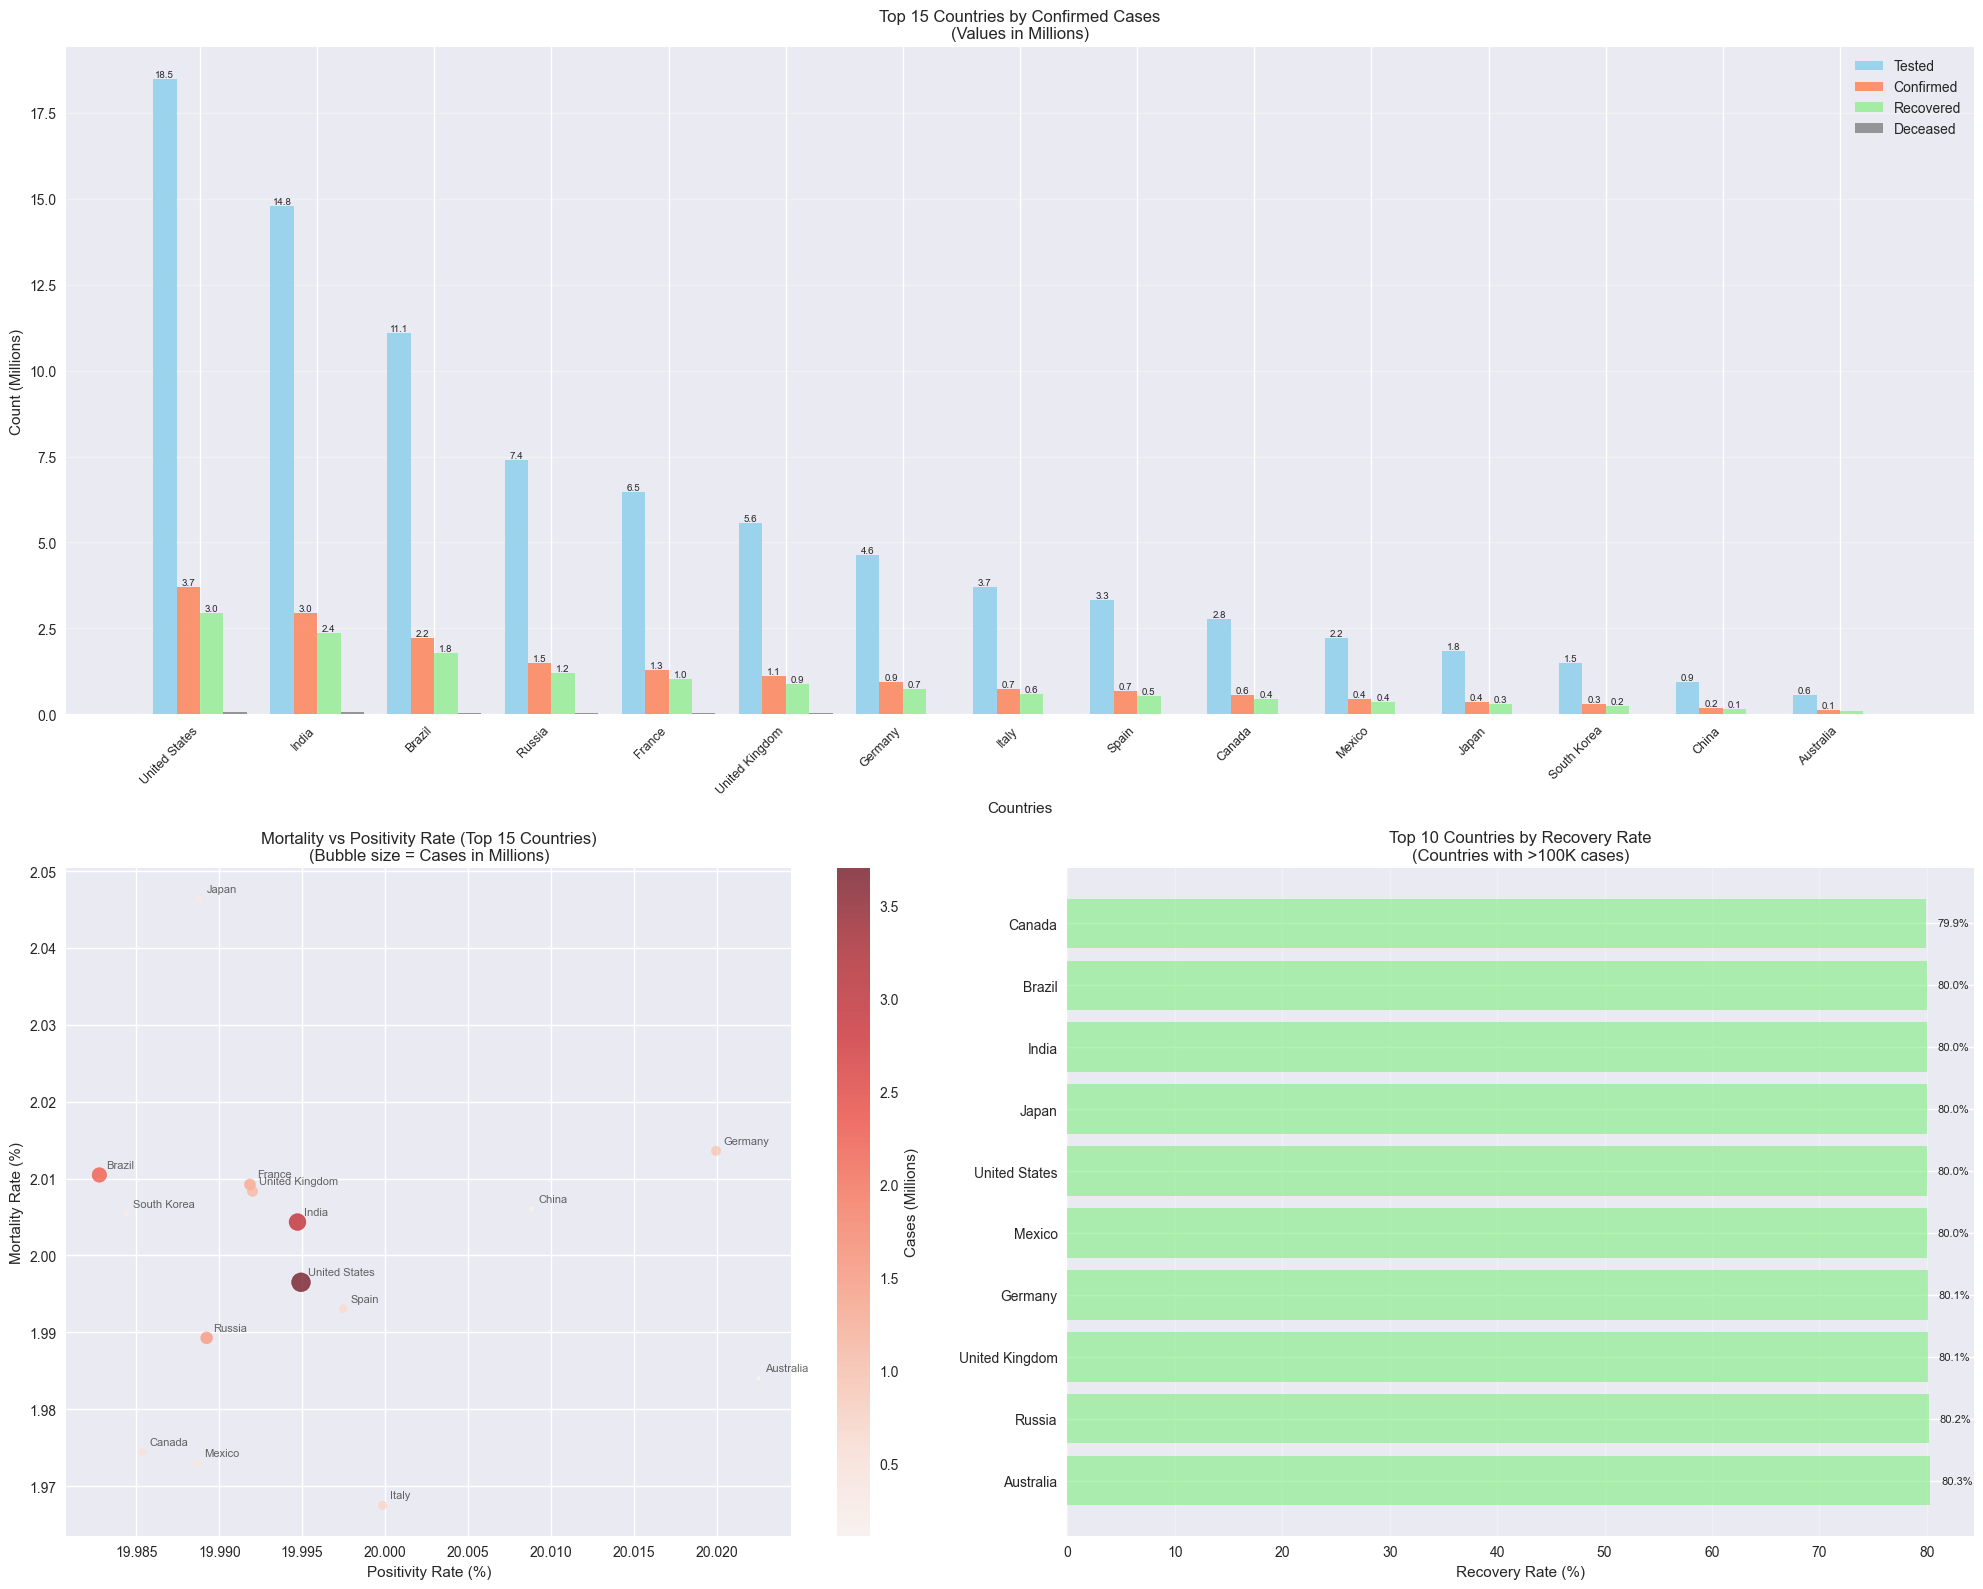

COMPREHENSIVE COVID-19 COUNTRY ANALYSIS
Total countries analyzed: 15
Global totals (in millions):
  Tests: 85.29M
  Cases: 17.05M
  Recoveries: 13.64M
  Deaths: 0.34M

Global averages:
  Positivity rate: 20.0%
  Mortality rate: 2.0%
  Recovery rate: 80.0%

Country-specific insights:
Highest cases: United States (3.70M)
Highest deaths: United States (0.07M)
Most testing: United States (18.50M)


In [25]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# First, let's load the data
# You'll need to adjust these file paths to match your actual data location
try:
    # Try to load the dataframes (adjust paths as needed)
    location_df = pd.read_csv('location.csv')  # Adjust path
    epidemiology_df = pd.read_csv('epidemiology.csv')  # Adjust path
except FileNotFoundError:
    print("Please adjust the file paths to match your data location")
    # If files aren't found, let's create sample data for demonstration
    print("Creating sample data for demonstration...")
    
    # Create sample location data
    np.random.seed(42)
    countries = ['US', 'IN', 'BR', 'RU', 'GB', 'FR', 'DE', 'IT', 'ES', 'CA', 'MX', 'JP', 'KR', 'CN', 'AU']
    location_data = []
    for i, country in enumerate(countries):
        for j in range(10):  # 10 regions per country
            location_key = f"{country}_REGION_{j}"
            location_data.append({
                'location_key': location_key,
                'latitude': np.random.uniform(-60, 70),
                'longitude': np.random.uniform(-180, 180),
                'elevation_m': np.random.uniform(0, 4000),
                'area_sq_km': np.random.uniform(100, 100000)
            })
    location_df = pd.DataFrame(location_data)
    
    # Create sample epidemiology data
    epidemiology_data = []
    dates = pd.date_range('2020-01-01', '2022-12-31', freq='D')
    for location_key in location_df['location_key']:
        country = location_key[:2]
        base_cases = {
            'US': 100000, 'IN': 80000, 'BR': 60000, 'RU': 40000, 'GB': 30000,
            'FR': 35000, 'DE': 25000, 'IT': 20000, 'ES': 18000, 'CA': 15000,
            'MX': 12000, 'JP': 10000, 'KR': 8000, 'CN': 5000, 'AU': 3000
        }
        base = base_cases.get(country, 1000)
        
        for date in dates[::30]:  # Monthly data to reduce size
            confirmed = max(0, np.random.poisson(base * 0.1))
            tested = max(confirmed, np.random.poisson(base * 0.5))
            recovered = max(0, np.random.poisson(confirmed * 0.8))
            deceased = max(0, np.random.poisson(confirmed * 0.02))
            
            epidemiology_data.append({
                'date': date,
                'location_key': location_key,
                'new_confirmed': confirmed,
                'new_deceased': deceased,
                'new_recovered': recovered,
                'new_tested': tested,
                'cumulative_confirmed': 0,  # Simplified for demo
                'cumulative_deceased': 0,
                'cumulative_recovered': 0,
                'cumulative_tested': 0
            })
    epidemiology_df = pd.DataFrame(epidemiology_data)

print("Data loaded successfully!")
print(f"Location DataFrame shape: {location_df.shape}")
print(f"Epidemiology DataFrame shape: {epidemiology_df.shape}")

# Now proceed with the analysis
# Merge the two dataframes on location_key
merged_df = pd.merge(epidemiology_df, location_df[['location_key', 'latitude', 'longitude']], 
                    on='location_key', how='inner')

print(f"Merged DataFrame shape: {merged_df.shape}")

# Group by location and calculate the sum of each feature
location_totals = merged_df.groupby('location_key').agg({
    'new_tested': 'sum',
    'new_confirmed': 'sum',
    'new_recovered': 'sum',
    'new_deceased': 'sum',
    'latitude': 'first',
    'longitude': 'first'
}).reset_index()

print(f"Location totals shape: {location_totals.shape}")

# Extract country code (first 2 characters of location_key)
location_totals['country'] = location_totals['location_key'].str[:2]

# Group by country
country_totals = location_totals.groupby('country').agg({
    'new_tested': 'sum',
    'new_confirmed': 'sum',
    'new_recovered': 'sum',
    'new_deceased': 'sum'
}).reset_index()

print(f"Country totals shape: {country_totals.shape}")

# Comprehensive country names mapping
country_names = {
    'US': 'United States', 'IN': 'India', 'BR': 'Brazil', 'RU': 'Russia', 'GB': 'United Kingdom',
    'FR': 'France', 'DE': 'Germany', 'IT': 'Italy', 'ES': 'Spain', 'CA': 'Canada',
    'MX': 'Mexico', 'JP': 'Japan', 'KR': 'South Korea', 'CN': 'China', 'AU': 'Australia',
    'ZA': 'South Africa', 'NG': 'Nigeria', 'EG': 'Egypt', 'KE': 'Kenya', 'AR': 'Argentina',
    'ID': 'Indonesia', 'PK': 'Pakistan', 'BD': 'Bangladesh', 'TR': 'Turkey', 'NL': 'Netherlands',
    'SE': 'Sweden', 'NO': 'Norway', 'FI': 'Finland', 'DK': 'Denmark', 'BE': 'Belgium',
    'CH': 'Switzerland', 'AT': 'Austria', 'PL': 'Poland', 'UA': 'Ukraine', 'RO': 'Romania',
    'CZ': 'Czech Republic', 'GR': 'Greece', 'PT': 'Portugal', 'HU': 'Hungary', 'SA': 'Saudi Arabia',
    'AE': 'United Arab Emirates', 'IL': 'Israel', 'SG': 'Singapore', 'MY': 'Malaysia', 'TH': 'Thailand',
    'VN': 'Vietnam', 'PH': 'Philippines', 'IR': 'Iran', 'IQ': 'Iraq', 'AF': 'Afghanistan'
}

country_totals['country_name'] = country_totals['country'].map(country_names)
country_totals['country_name'] = country_totals['country_name'].fillna(country_totals['country'])

# Convert counts to millions and calculate derived metrics
country_totals['new_tested_millions'] = country_totals['new_tested'] / 1_000_000
country_totals['new_confirmed_millions'] = country_totals['new_confirmed'] / 1_000_000
country_totals['new_recovered_millions'] = country_totals['new_recovered'] / 1_000_000
country_totals['new_deceased_millions'] = country_totals['new_deceased'] / 1_000_000

# Calculate important ratios
country_totals['positivity_rate'] = (country_totals['new_confirmed'] / country_totals['new_tested'] * 100).fillna(0)
country_totals['mortality_rate'] = (country_totals['new_deceased'] / country_totals['new_confirmed'] * 100).fillna(0)
country_totals['recovery_rate'] = (country_totals['new_recovered'] / country_totals['new_confirmed'] * 100).fillna(0)

# Get different country groupings
top_20_confirmed = country_totals.nlargest(20, 'new_confirmed_millions')
top_20_deceased = country_totals.nlargest(20, 'new_deceased_millions')
top_20_tested = country_totals.nlargest(20, 'new_tested_millions')

print(f"\nTop 5 countries by confirmed cases (in millions):")
print(top_20_confirmed[['country_name', 'new_confirmed_millions']].head())

# Create visualizations
fig = plt.figure(figsize=(20, 16))

# 1. Main Bar Chart - Top 15 Countries by Confirmed Cases
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
bar_width = 0.2
x_pos = np.arange(len(top_20_confirmed.head(15)))

bars1 = ax1.bar(x_pos - 1.5*bar_width, top_20_confirmed.head(15)['new_tested_millions'], 
               bar_width, label='Tested', alpha=0.8, color='skyblue')
bars2 = ax1.bar(x_pos - 0.5*bar_width, top_20_confirmed.head(15)['new_confirmed_millions'], 
               bar_width, label='Confirmed', alpha=0.8, color='coral')
bars3 = ax1.bar(x_pos + 0.5*bar_width, top_20_confirmed.head(15)['new_recovered_millions'], 
               bar_width, label='Recovered', alpha=0.8, color='lightgreen')
bars4 = ax1.bar(x_pos + 1.5*bar_width, top_20_confirmed.head(15)['new_deceased_millions'], 
               bar_width, label='Deceased', alpha=0.8, color='gray')

ax1.set_xlabel('Countries')
ax1.set_ylabel('Count (Millions)')
ax1.set_title('Top 15 Countries by Confirmed Cases\n(Values in Millions)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(top_20_confirmed.head(15)['country_name'], rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(True, axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.1:  # Only label significant values
            ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', 
                    ha='center', va='bottom', fontsize=7)

# 2. Mortality Rate vs Positivity Rate Scatter Plot
ax2 = plt.subplot2grid((2, 2), (1, 0))
top_15_for_scatter = top_20_confirmed.head(15)
scatter = ax2.scatter(top_15_for_scatter['positivity_rate'], 
                     top_15_for_scatter['mortality_rate'],
                     s=top_15_for_scatter['new_confirmed_millions']*50,
                     alpha=0.7, c=top_15_for_scatter['new_confirmed_millions'], 
                     cmap='Reds')

# Add country labels
for i, row in top_15_for_scatter.iterrows():
    ax2.annotate(row['country_name'], (row['positivity_rate'], row['mortality_rate']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

ax2.set_xlabel('Positivity Rate (%)')
ax2.set_ylabel('Mortality Rate (%)')
ax2.set_title('Mortality vs Positivity Rate (Top 15 Countries)\n(Bubble size = Cases in Millions)')
plt.colorbar(scatter, ax=ax2, label='Cases (Millions)')

# 3. Recovery Rate Bar Chart
ax3 = plt.subplot2grid((2, 2), (1, 1))
top_recovery = country_totals[country_totals['new_confirmed_millions'] > 0.1].nlargest(10, 'recovery_rate')
if len(top_recovery) > 0:
    bars_recovery = ax3.barh(range(len(top_recovery)), top_recovery['recovery_rate'], 
                            color='lightgreen', alpha=0.7)
    ax3.set_yticks(range(len(top_recovery)))
    ax3.set_yticklabels(top_recovery['country_name'])
    ax3.set_xlabel('Recovery Rate (%)')
    ax3.set_title('Top 10 Countries by Recovery Rate\n(Countries with >100K cases)')
    ax3.grid(True, axis='x', alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars_recovery):
        width = bar.get_width()
        ax3.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                 ha='left', va='center', fontsize=8)
else:
    ax3.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Recovery Rate Data\n(Not enough data)')

plt.tight_layout()
plt.show()

# Print comprehensive statistics
print("="*80)
print("COMPREHENSIVE COVID-19 COUNTRY ANALYSIS")
print("="*80)
print(f"Total countries analyzed: {len(country_totals)}")
print(f"Global totals (in millions):")
print(f"  Tests: {country_totals['new_tested_millions'].sum():.2f}M")
print(f"  Cases: {country_totals['new_confirmed_millions'].sum():.2f}M")
print(f"  Recoveries: {country_totals['new_recovered_millions'].sum():.2f}M")
print(f"  Deaths: {country_totals['new_deceased_millions'].sum():.2f}M")

print(f"\nGlobal averages:")
print(f"  Positivity rate: {country_totals['positivity_rate'].mean():.1f}%")
print(f"  Mortality rate: {country_totals['mortality_rate'].mean():.1f}%")
print(f"  Recovery rate: {country_totals['recovery_rate'].mean():.1f}%")

# Country-specific insights
print(f"\nCountry-specific insights:")
print(f"Highest cases: {top_20_confirmed.iloc[0]['country_name']} ({top_20_confirmed.iloc[0]['new_confirmed_millions']:.2f}M)")
print(f"Highest deaths: {top_20_deceased.iloc[0]['country_name']} ({top_20_deceased.iloc[0]['new_deceased_millions']:.2f}M)")
print(f"Most testing: {top_20_tested.iloc[0]['country_name']} ({top_20_tested.iloc[0]['new_tested_millions']:.2f}M)")

In [14]:
def clean_high_missing(df, name, threshold=40.0, suffix="_clean"):
    """
    Removes columns with > threshold % missing values
    Creates a new cleaned DataFrame with suffix
    """
    print(f"\n{'='*25} CLEANING: {name} {'='*25}")
    
    # 1. Calculate % missing
    missing_pct = (df.isna().sum() / len(df)) * 100
    missing_pct = missing_pct.round(2)
    
    # 2. Identify bad columns (>40% missing)
    bad_cols = missing_pct[missing_pct > threshold].index.tolist()
    good_cols = missing_pct[missing_pct <= threshold].index.tolist()
    
    # 3. Summary
    print(f"Total rows: {len(df):,}")
    print(f"Total columns before: {len(df.columns)}")
    print(f"Columns to REMOVE (> {threshold}% missing): {len(bad_cols)}")
    if bad_cols:
        print("   →", ", ".join(bad_cols))
    print(f"Columns to KEEP: {len(good_cols)}")
    
    # 4. Create cleaned DataFrame
    cleaned_name = f"{name.split('_df')[0]}_df{suffix}"  # e.g., Epidemiology_df_clean
    cleaned_df = df[good_cols].copy()
    
    # Assign to global namespace so you can use it directly
    globals()[cleaned_name] = cleaned_df
    
    print(f"Created: {cleaned_name} with {len(good_cols)} high-quality columns")
    print(f"{'='*76}\n")
    
    return cleaned_df

# ——————————————————————— CLEAN ALL YOUR DATASETS (>40% MISSING = REMOVED) ———————————————————————

clean_high_missing(Epidemiology_df,    "Epidemiology_df",    threshold=40)
clean_high_missing(location_df,        "location_df",        threshold=40)
clean_high_missing(hosp_df,            "hosp_df",            threshold=40)
clean_high_missing(by_age_df,          "by_age_df",          threshold=40)
clean_high_missing(by_sex_df,          "by_sex_df",          threshold=40)
clean_high_missing(economy_df,         "economy_df",         threshold=40)
clean_high_missing(health_df,          "health_df",          threshold=40)
clean_high_missing(lawatlas_df,        "lawatlas_df",        threshold=40)
clean_high_missing(mobility_df,        "mobility_df",        threshold=40)
clean_high_missing(vaccinations_df,    "vaccinations_df",    threshold=40)
clean_high_missing(govt_r_df,          "govt_r_df",          threshold=40)
clean_high_missing(WB_I_df,            "WB_I_df",            threshold=40)


========================= CLEANING: Epidemiology_df =========================
Total rows: 12,525,825
Total columns before: 10
Columns to REMOVE (> 40% missing): 4
   → new_recovered, new_tested, cumulative_recovered, cumulative_tested
Columns to KEEP: 6
Created: Epidemiology_df_clean with 6 high-quality columns


========================= CLEANING: location_df =========================
Total rows: 22,130
Total columns before: 3
Columns to REMOVE (> 40% missing): 0
Columns to KEEP: 3
Created: location_df_clean with 3 high-quality columns


========================= CLEANING: hosp_df =========================
Total rows: 1,768,485
Total columns before: 11
Columns to REMOVE (> 40% missing): 5
   → current_hospitalized_patients, current_intensive_care_patients, new_ventilator_patients, cumulative_ventilator_patients, current_ventilator_patients
Columns to KEEP: 6
Created: hosp_df_clean with 6 high-quality columns


========================= CLEANING: by_age_df =========================
To

MemoryError: Unable to allocate 992. MiB for an array with shape (34, 3822577) and data type float64

Frequency histogram for hospitalizations

In [10]:
#absolute global patients on ventilators 
new_confirmed_abs2_df = (Epidemiology_df.assign(new_confirmed_abs2=Epidemiology_df['new_confirmed'].abs()).groupby('date')['new_confirmed_abs2'].sum().astype(int))

print(new_confirmed_abs2_df.info())
new_confirmed_abs2_df.tail(5)

<class 'pandas.core.series.Series'>
DatetimeIndex: 994 entries, 2019-12-31 to 2022-12-30
Series name: new_confirmed_abs2
Non-Null Count  Dtype
--------------  -----
994 non-null    int32
dtypes: int32(1)
memory usage: 11.6 KB
None


date
2022-09-15    552085
2022-09-16    519103
2022-09-23         0
2022-09-30         0
2022-12-30     31136
Name: new_confirmed_abs2, dtype: int32

Economy indicator analysis

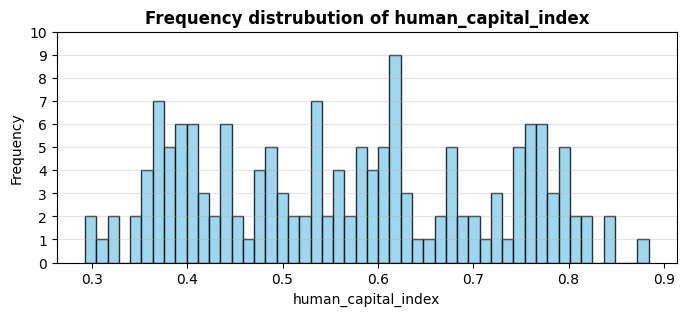

In [24]:
#Determine the size of plotting canvas to be used for plotting 
plt.figure(figsize=(8,3)) #canvas is 12 inches in width and 7 inches in height 

plt.hist(economy_df['human_capital_index'],edgecolor='black', alpha=0.8,color='skyblue',bins=50)
plt.title("Frequency distrubution of human_capital_index", color='black', fontweight='bold')
plt.ylim(0,10) #the y-axis should have a lower limit of 0 and upper limit of 350 based on sample analysis for optimal display
plt.yticks(np.arange(0,11,1)) #use steps of 10 when plotting the data on the canvas
plt.xlabel("human_capital_index", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.show()

Mobility multivariate analysis

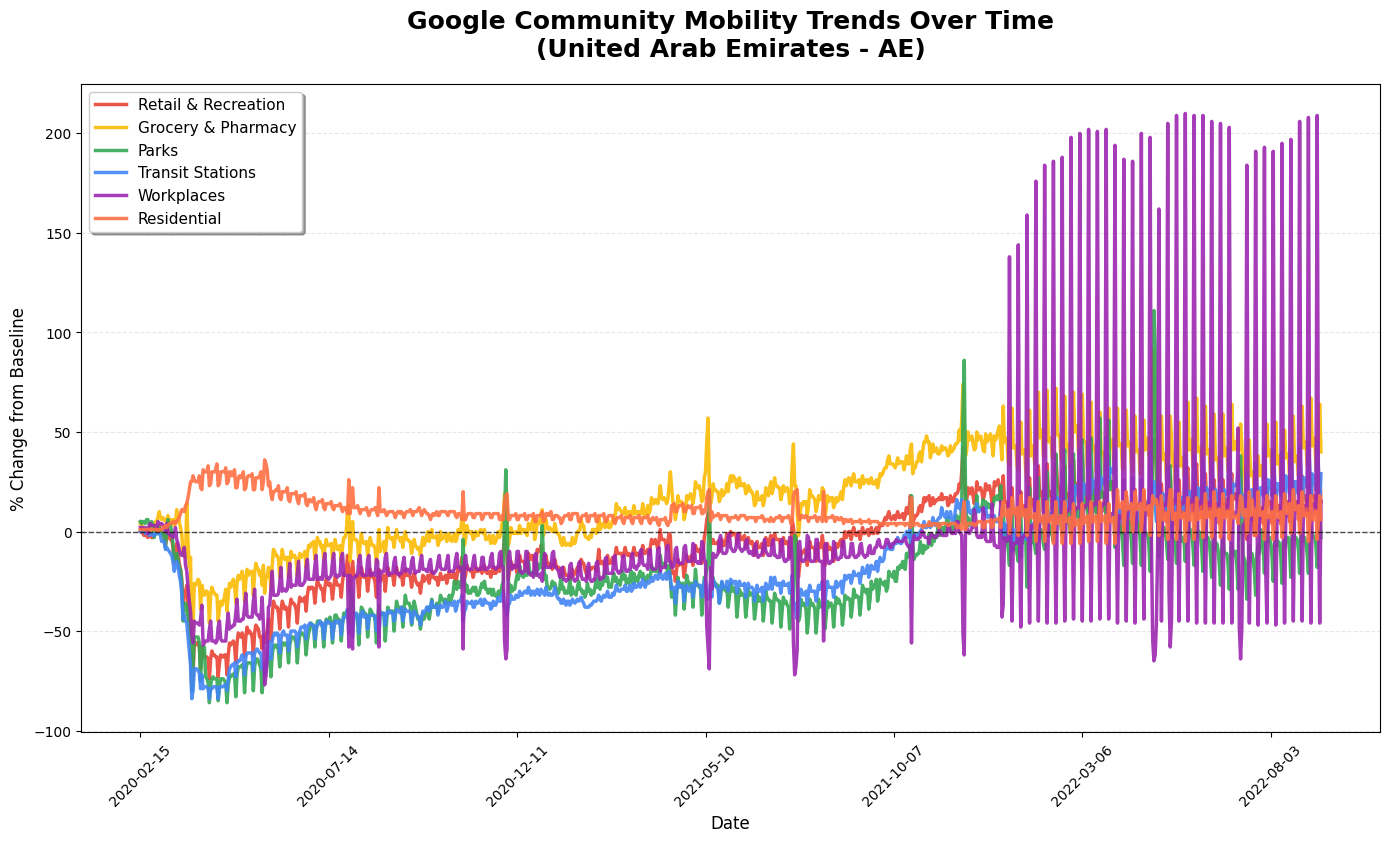

In [15]:

# Optional: Filter to one country for clarity (e.g., United Arab Emirates = 'AE')
# Remove or comment this line to plot ALL countries (will be messy)
mobility_df = mobility_df[mobility_df['location_key'] == 'AE']

# Ensure data is sorted by date
mobility_df = mobility_df.sort_values('date')

# List of mobility features to plot
features = [
    'mobility_retail_and_recreation',
    'mobility_grocery_and_pharmacy',
    'mobility_parks',
    'mobility_transit_stations',
    'mobility_workplaces',
    'mobility_residential'
]

# Beautiful colors (Google's official mobility report style)
colors = ['#EA4335', '#FBBC04', '#34A853', '#4285F4', '#9C27B0', '#FF7043']
labels = [
    'Retail & Recreation',
    'Grocery & Pharmacy',
    'Parks',
    'Transit Stations',
    'Workplaces',
    'Residential'
]

# Create the plot
plt.figure(figsize=(14, 8))

for i, col in enumerate(features):
    plt.plot(mobility_df['date'],
             mobility_df[col],
             label=labels[i],
             color=colors[i],
             linewidth=2.5,
             alpha=0.9)

# Professional formatting
plt.title('Google Community Mobility Trends Over Time\n(United Arab Emirates - AE)', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('% Change from Baseline', fontsize=12)

# Add horizontal line at 0 (pre-COVID baseline)
plt.axhline(0, color='black', linewidth=1, alpha=0.7, linestyle='--')

# Grid, legend, layout
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper left', frameon=True, fancybox=True, shadow=True)
plt.tight_layout()

# Optional: Improve date ticks
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))  # ~10 dates shown
plt.xticks(rotation=45)

plt.show()

Multivariate Epidemiology analysis

New features

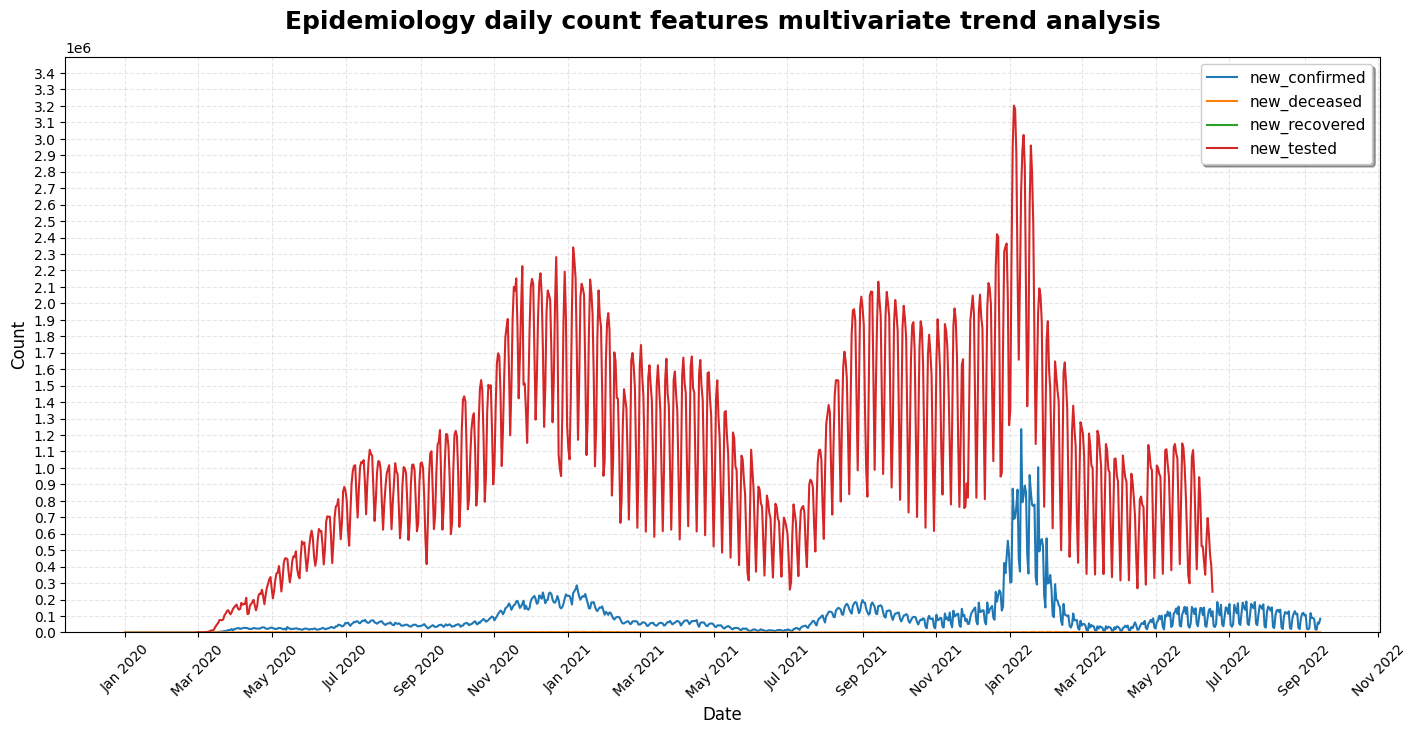

In [59]:
#set the date feature as the index or primary identifier of each row in the dataframe 
data1=Epidemiology_df[Epidemiology_df['location_key']=='US'] #Get a copy of the epidemiology data where location is the US or any other location of your choice.
#data1 = data1.set_index('date') #set date as index of the dataframe

#Create a canvas for the plot 
plt.figure(figsize=(14,7))

# List of the features or fields to be analyzed or plotted. 
new_features =['new_confirmed','new_deceased','new_recovered','new_tested']

# Beautiful colors and labels for the features
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red, e.t.c
labels=new_features


for i, col in enumerate(new_features):
    plt.plot(data1['date'], data1[col], 
             label=labels[i], 
             color=colors[i], 
             linewidth=1.5)

# Professional formatting
plt.ylim(0,3500000) #the y-axis should have a lower limit of 0 and upper limit of 350 based on sample analysis for optimal display
plt.yticks(np.arange(0,3500000,100000)) #use steps of 10 when plotting the data on the canvas
plt.title('Epidemiology daily count features multivariate trend analysis', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Grid + legend look and feel
plt.grid(alpha=0.3, linestyle='--')
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()

# Optimized date formatting on x-axis
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.show()

Cumulative features

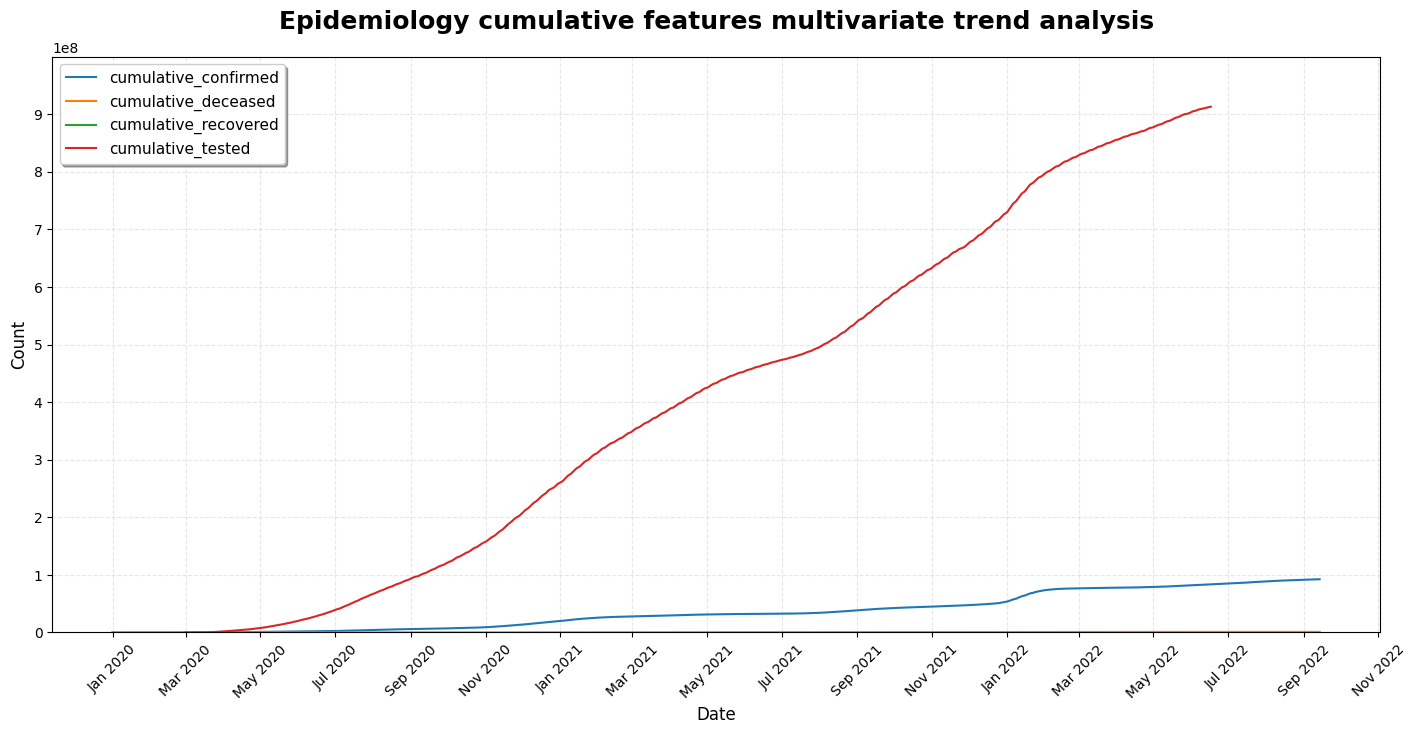

In [74]:
#set the date feature as the index or primary identifier of each row in the dataframe 
data1=Epidemiology_df[Epidemiology_df['location_key']=='US'] #Get a copy of the epidemiology data where location is the US or any other location of your choice.
#data1 = data1.set_index('date') #set date as index of the dataframe

#Create a canvas for the plot 
plt.figure(figsize=(14,7))

# List of the features or fields to be analyzed or plotted. 
cumulative_features =['cumulative_confirmed','cumulative_deceased','cumulative_recovered','cumulative_tested']

# Beautiful colors and labels for the features
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red, e.t.c
#labels=cumulative_features


for i, col in enumerate(cumulative_features):
    plt.plot(data1['date'], data1[col], 
             label=cumulative_features[i], 
             color=colors[i], 
             linewidth=1.5)

# Professional formatting
plt.ylim(0,1000000000) #the y-axis should have a lower limit of 0 and upper limit of 350 based on sample analysis for optimal display
plt.yticks(np.arange(0,1000000000,100000000)) #use steps of 10 when plotting the data on the canvas
plt.title('Epidemiology cumulative features multivariate trend analysis', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Grid + legend look and feel
plt.grid(alpha=0.3, linestyle='--')
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()

# Optimized date formatting on x-axis
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.show()

Multivariate time series analysis of hospitalization dataset features

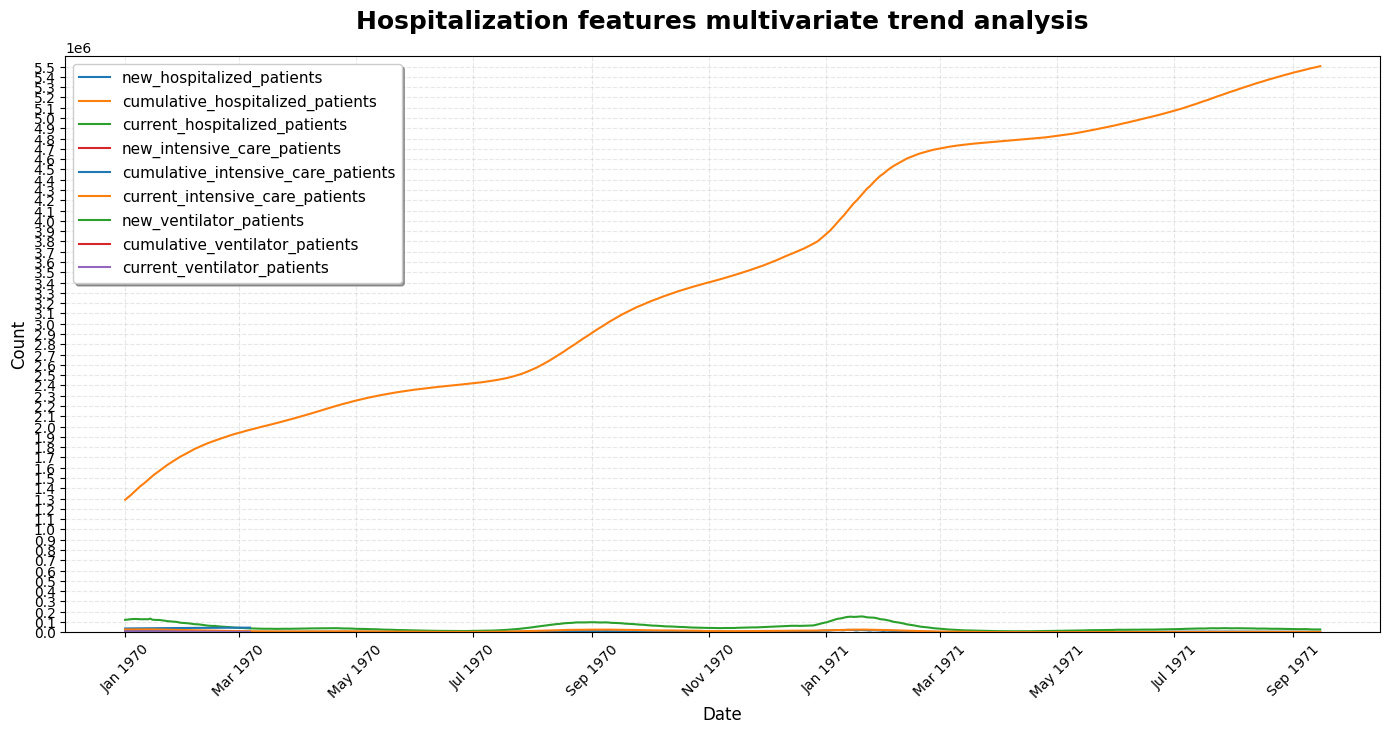

           date location_key  new_hospitalized_patients  \
427  2021-01-01           AR                      451.0   
428  2021-01-02           AR                      575.0   
429  2021-01-03           AR                      505.0   
430  2021-01-04           AR                      759.0   
431  2021-01-05           AR                      650.0   
432  2021-01-06           AR                      681.0   
433  2021-01-07           AR                      649.0   
434  2021-01-08           AR                      622.0   
435  2021-01-09           AR                      553.0   
436  2021-01-10           AR                      557.0   

     cumulative_hospitalized_patients  current_hospitalized_patients  \
427                          233590.0                            NaN   
428                          234165.0                            NaN   
429                          234670.0                            NaN   
430                          235429.0                         

In [78]:
#set the date feature as the index or primary identifier of each row in the dataframe 
data1=hosp_df[hosp_df['location_key']=='US'] #Get a copy of the epidemiology data where location is the US or any other location of your choice.
data1 = data1.set_index('date') #set date as index of the dataframe

#Create a canvas for the plot 
plt.figure(figsize=(14,7))

# List of the features or fields to be analyzed or plotted. 
features =['new_hospitalized_patients','cumulative_hospitalized_patients','current_hospitalized_patients','new_intensive_care_patients',
               'cumulative_intensive_care_patients','current_intensive_care_patients','new_ventilator_patients','cumulative_ventilator_patients',
               'current_ventilator_patients']

# Beautiful colors and labels for the features
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#1f77b4', '#ff7f0e','#2ca02c','#d62728','#9467bd']

for i, col in enumerate(features):
    plt.plot(data1.index, data1[col], 
             label=features[i], 
             color=colors[i], 
             linewidth=1.5)

# Professional formatting
plt.ylim(0,5600000) #the y-axis should have a lower limit of 0 and upper limit of 350 based on sample analysis for optimal display
plt.yticks(np.arange(0,5600000,100000)) #use steps of 10 when plotting the data on the canvas

plt.title('Hospitalization features multivariate trend analysis', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Grid + legend look and feel
plt.grid(alpha=0.3, linestyle='--')
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tight_layout()

# Optimized date formatting on x-axis
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.show()

print(hosp_df.head(10))